In [1]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
from scipy.integrate import dblquad, tplquad, trapezoid
from src.ThreeBodyCapture.Simulations.montecarlo import MonteCarloSimulation
from src.ThreeBodyCapture.Simulations.rebound import OrbitalSimulation
import src.Utils.calculations as calc
import multiprocessing
import datetime
from numpy.random import SeedSequence, Generator, PCG64
import src.ThreeBodyCapture.Simulations.montecarlo_impsamp as mc_imp

mPBH: 1.99e+22 kg, 1.00e-08 M_sun
mPBH: 1.99e+23 kg, 1.00e-07 M_sun
mPBH: 1.99e+24 kg, 1.00e-06 M_sun
mPBH: 1.99e+25 kg, 1.00e-05 M_sun
mPBH: 1.99e+26 kg, 1.00e-04 M_sun
mPBH: 1.99e+27 kg, 1.00e-03 M_sun
mPBH: 1.99e+28 kg, 1.00e-02 M_sun


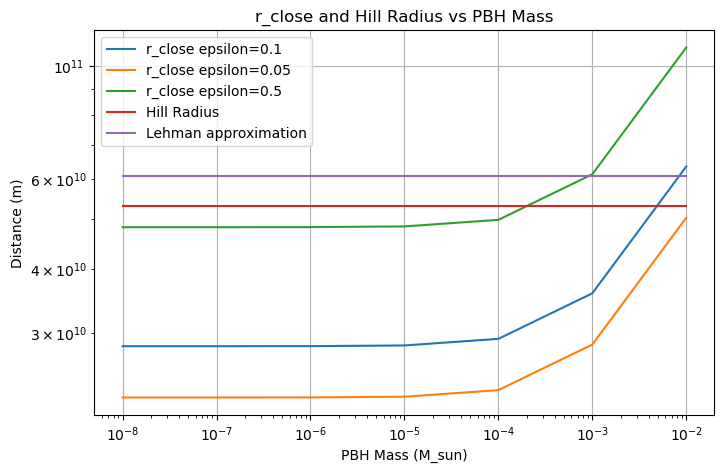

0.7319409264918294


<Figure size 640x480 with 0 Axes>

In [12]:
G = const.G.value
m_Sun = const.M_sun.value
m_Jup =  const.M_jup.value  # Mass of Jupiter
m_Neptune = 5.15*10**-5 * const.M_sun.value  # Mass of Neptune
m_PBH = 1e-13 * const.M_sun.value
r_SJ = (5.2*u.au).to(u.m).value
r_SN = (30.07*u.au).to(u.m).value
v_Jup = 13.06 * 1e3  # km/s to m/s
v_Neptune = 5.45 * 1e3  # km/s to m/s
epsilon = 0.1
v_inf = 20.23 * 1e3  # km/s to m/s
r_jupiter = const.R_jup.to(u.m).value
r_neptune = 24622 * 1e3  # in meters
A_jupiter = np.pi * r_jupiter**2
mPBH_grid = np.logspace(np.log10(1e-8), np.log10(1e-2), 7) * const.M_sun.value  # from 1e-10 to 1 solar mass
rc = []
rcad = []
rctest = []
rh = []
epsilon = 0.5
rc_lehman = []
for mpbh in mPBH_grid:
    muA = calc.standard_gravitational_parameter(m_Sun, mpbh)
    muB = calc.standard_gravitational_parameter(m_Jup, mpbh)
    print(f"mPBH: {mpbh:.2e} kg, {mpbh/const.M_sun.value:.2e} M_sun")
    rclose = calc.r_close(0.1, muA, muB, r_SJ)
    rc.append(rclose)
    rcadj = calc.r_close(0.05, muA, muB, r_SJ)
    rcad.append(rcadj)
    rctest.append(calc.r_close(epsilon, muA, muB, r_SJ))
    rhill = calc.hill_radius(r_SJ, m_Sun, m_Jup )
    rh.append(rhill)
    rclose_lehman = r_SJ * (epsilon*m_Jup/m_Sun)**(1/3)
    rc_lehman.append(rclose_lehman)
plt.figure(figsize=(8, 5))
plt.plot(mPBH_grid/const.M_sun.value, rc, label='r_close epsilon=0.1')
plt.plot(mPBH_grid/const.M_sun.value, rcad, label='r_close epsilon=0.05')
plt.plot(mPBH_grid/const.M_sun.value, rctest, label=f'r_close epsilon={epsilon}')
plt.plot(mPBH_grid/const.M_sun.value, rh, label='Hill Radius')
plt.plot(mPBH_grid/const.M_sun.value, rc_lehman, label='Lehman approximation')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('PBH Mass (M_sun)')
plt.ylabel('Distance (m)')
plt.title('r_close and Hill Radius vs PBH Mass')
plt.legend()
plt.grid()
plt.show()
plt.savefig('r_close_hill_radius.png', bbox_inches='tight')
print((np.array(rc_lehman[0])-np.array(rc[0]))/((np.array(rc_lehman[0])+np.array(rc[0]))/2))

orbital velocity of B: 13061.451410903353
Escape velocity v_esc: 18471.681729576718
Maximum incoming velocity v_max: 40505.49297393395
Orbital period of B: 4329.08640202434 days
radius of B: 0.24984484570011387 au
radius of C: 1.9741257427538034e-08 au
0.24984484570011387
epsilon: 1.16e-01
r_hill: 0.3548932467331163 au
 aB to rclose ratio: 20.81291685417239 aB to rhill ratio: 14.652293465337362
safranov number 10.386999620634544
{'name': 'Sun-Jupiter', 'mA': np.float64(1.988409870698051e+30), 'mB': np.float64(1.8981245973360505e+27), 'mC': np.float64(1.988409870698051e+30), 'aB': np.float64(777908927640.0), 'rB': np.float64(71492000.0), 'vB': np.float64(13061.451410903353), 'eB': 0, 'iB': 0, 'epsilon': np.float64(0.11619363689086676), 'seed_base': 42}
mPBH: 1.99e+22 kg, 1.00e-08 M_sun
mPBH: 1.99e+23 kg, 1.00e-07 M_sun
mPBH: 1.99e+24 kg, 1.00e-06 M_sun
mPBH: 1.99e+25 kg, 1.00e-05 M_sun
mPBH: 1.99e+26 kg, 1.00e-04 M_sun
mPBH: 1.99e+27 kg, 1.00e-03 M_sun
mPBH: 1.99e+28 kg, 1.00e-02 M_sun


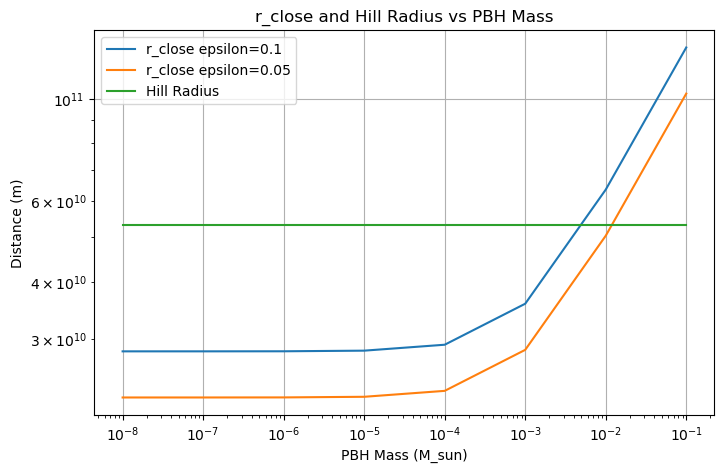

In [16]:
s = datetime.datetime.now()
G = const.G.value
name = "Sun-Jupiter"
v_inf_grid = np.linspace(1e3, (544e3), 20) # from 1 km/s to 800 km/s, Maximum incoming velocity v_max: 40498.00358610428
m_Sun = const.M_sun.value
m_Jup =  const.M_jup.value  # Mass of Jupiter
m_Neptune = 5.15*10**-5 * const.M_sun.value  # Mass of Neptune
m_PBH = 1e-13 * const.M_sun.value
r_SJ = (5.2*u.au).to(u.m).value
r_SN = (30.07*u.au).to(u.m).value
v_Jup = 13.06 * 1e3  # km/s to m/s
v_Neptune = 5.45 * 1e3  # km/s to m/s
epsilon = 0.1
v_inf = 20.23 * 1e3  # km/s to m/s
r_jupiter = const.R_jup.to(u.m).value
r_neptune = 24622 * 1e3  # in meters
r_sun = const.R_sun.to(u.m).value
e_jupiter = 0.0489
i_jupiter = 1.304 * (np.pi/180)
A_jupiter = np.pi * r_jupiter**2

aB = r_SJ
mA = m_Sun
mB = m_Jup
rA = r_sun
rB = r_jupiter
m_PBH = m_Sun
muA = G * mA
muB = G * mB
vBMag = np.sqrt(muA/aB)
eB = 0
rC_rH_ratio = 0.7040
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
seed = 42
system_param_dict = {
    'name': name,
    'mA': mA,
    'mB': mB,
    'mC' : m_PBH,
    'aB': aB,
    'rB': rB,
    'vB' : vBMag,
    'eB' : 0,
    'iB' : 0,
    'epsilon': epsilon,
    'seed_base': seed,
}
safranov_number = (mB/mA) * (aB/r_jupiter)

trials = 10_000_000
sample_size = 200
lambda_limits = [0, 2*np.pi]
cosbeta_limits = [-1, 1]   # cosβ
phi_limits = [0, 2 * np.pi]
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
vesc = calc.v_esc(muA, aB)
# rclose = calc.r_close(epsilon, mA, mB, aB)
vmax = vesc + 2*vBMag
vinf_max = np.sqrt(vmax**2 - (2 * muA / aB) - (2 * muB / rclose))
print(f'orbital velocity of B: {vBMag}')
print("Escape velocity v_esc:", vesc)
print("Maximum incoming velocity v_max:", vinf_max)
T =2*np.pi*np.sqrt(aB**3/(G*(mA + mB)))
print(f'Orbital period of B: {T/(3600*24)} days')
print(f'radius of B: {rclose*u.m.to(u.au)} au')
print(f'radius of C: {calc.schwarzchild_radius(m_PBH)*u.m.to(u.au)} au')
print(rclose*u.m.to(u.au))
print(f"epsilon: {epsilon:.2e}")
print(f"r_hill: {r_hill*u.m.to(u.au)} au")
print(f" aB to rclose ratio: {aB/rclose} aB to rhill ratio: {aB/r_hill}")
print(f"safranov number {safranov_number}")

print(system_param_dict)
rc = []
rcad = []
rh = []
for mpbh in mPBH_grid:
    muA = calc.standard_gravitational_parameter(mA,mpbh)
    muB =  calc.standard_gravitational_parameter(mB, mpbh)
    print(f"mPBH: {mpbh:.2e} kg, {mpbh/const.M_sun.value:.2e} M_sun")
    rclose = calc.r_close(0.1, muA, muB, aB)
    rc.append(rclose)
    rcadj = calc.r_close(0.05, muA, muB, aB)
    rcad.append(rcadj)
    rhill = calc.hill_radius(aB, mA, mB, eB)
    rh.append(rhill)
plt.figure(figsize=(8, 5))
plt.plot(mPBH_grid/const.M_sun.value, rc, label='r_close epsilon=0.1')
plt.plot(mPBH_grid/const.M_sun.value, rcad, label='r_close epsilon=0.05')
plt.plot(mPBH_grid/const.M_sun.value, rh, label='Hill Radius')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('PBH Mass (M_sun)')
plt.ylabel('Distance (m)')
plt.title('r_close and Hill Radius vs PBH Mass')
plt.legend()
plt.grid()
plt.show()
rcsj = rc

orbital velocity of B: 13061.451410903353
Escape velocity v_esc: 18471.681729576718
Maximum incoming velocity v_max: 40587.29399094213
Orbital period of B: 4331.14566533829 days
radius of B: 0.03662215095639646 au
radius of C: 1.9741257427538034e-08 au
0.03662215095639646
epsilon: 1.16e-01
r_hill: 0.05202010079033588 au
 aB to rclose ratio: 141.9905675718308 aB to rhill ratio: 99.96135957056889
safranov number 0.3663224437595338
{'name': 'Sun-Earth', 'mA': np.float64(1.988409870698051e+30), 'mB': np.float64(5.972167867791379e+24), 'mC': np.float64(1.988409870698051e+30), 'aB': np.float64(777908927640.0), 'rB': np.float64(6378100.0), 'vB': np.float64(13061.451410903353), 'eB': 0, 'iB': 0, 'epsilon': np.float64(0.11630420534822472), 'seed_base': 42}
mPBH: 1.99e+22 kg, 1.00e-08 M_sun
mPBH: 1.99e+23 kg, 1.00e-07 M_sun
mPBH: 1.99e+24 kg, 1.00e-06 M_sun
mPBH: 1.99e+25 kg, 1.00e-05 M_sun
mPBH: 1.99e+26 kg, 1.00e-04 M_sun
mPBH: 1.99e+27 kg, 1.00e-03 M_sun
mPBH: 1.99e+28 kg, 1.00e-02 M_sun
mPBH

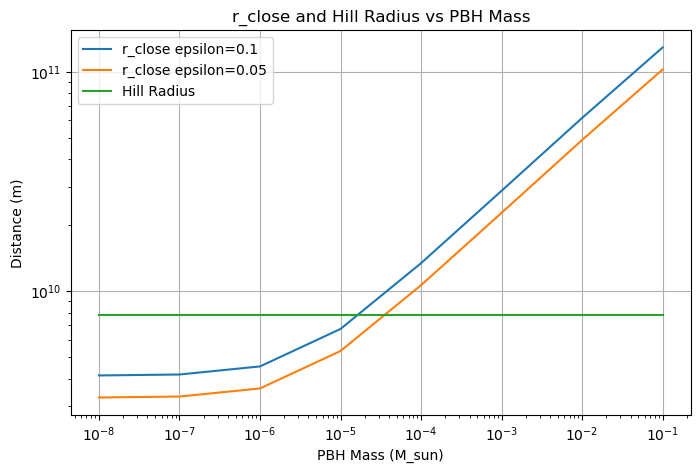

In [15]:
s = datetime.datetime.now()
G = const.G.value
name = "Sun-Earth"
v_inf_grid = np.linspace(1e3, (544e3), 20) # from 1 km/s to 800 km/s, Maximum incoming velocity v_max: 40498.00358610428
m_Sun = const.M_sun.value
m_Earth =  const.M_earth.value  # Mass of Earth
m_Neptune = 5.15*10**-5 * const.M_sun.value  # Mass of Neptune
m_PBH = 1e-13 * const.M_sun.value
r_SE = (5.2*u.au).to(u.m).value
r_SN = (30.07*u.au).to(u.m).value
v_Earth = 29.78 * 1e3  # km/s to m/s
v_Neptune = 5.45 * 1e3  # km/s to m/s
epsilon = 0.1
v_inf = 20.23 * 1e3  # km/s to m/s
r_earth = const.R_earth.to(u.m).value
r_neptune = 24622 * 1e3  # in meters
r_sun = const.R_sun.to(u.m).value
e_jupiter = 0.0489
i_jupiter = 1.304 * (np.pi/180)

aB = r_SE
mA = m_Sun
mB = m_Earth
rA = r_sun
rB = r_earth
m_PBH = m_Sun
muA = G * mA
muB = G * mB
vBMag = np.sqrt(muA/aB)
eB = 0
rC_rH_ratio = 0.7040
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
seed = 42
system_param_dict = {
    'name': name,
    'mA': mA,
    'mB': mB,
    'mC' : m_PBH,
    'aB': aB,
    'rB': rB,
    'vB' : vBMag,
    'eB' : 0,
    'iB' : 0,
    'epsilon': epsilon,
    'seed_base': seed,
}
safranov_number = (mB/mA) * (aB/r_earth)

trials = 10_000_000
sample_size = 200
lambda_limits = [0, 2*np.pi]
cosbeta_limits = [-1, 1]   # cosβ
phi_limits = [0, 2 * np.pi]
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
vesc = calc.v_esc(muA, aB)
# rclose = calc.r_close(epsilon, mA, mB, aB)
vmax = vesc + 2*vBMag
vinf_max = np.sqrt(vmax**2 - (2 * muA / aB) - (2 * muB / rclose))
print(f'orbital velocity of B: {vBMag}')
print("Escape velocity v_esc:", vesc)
print("Maximum incoming velocity v_max:", vinf_max)
T =2*np.pi*np.sqrt(aB**3/(G*(mA + mB)))
print(f'Orbital period of B: {T/(3600*24)} days')
print(f'radius of B: {rclose*u.m.to(u.au)} au')
print(f'radius of C: {calc.schwarzchild_radius(m_PBH)*u.m.to(u.au)} au')
print(rclose*u.m.to(u.au))
print(f"epsilon: {epsilon:.2e}")
print(f"r_hill: {r_hill*u.m.to(u.au)} au")
print(f" aB to rclose ratio: {aB/rclose} aB to rhill ratio: {aB/r_hill}")
print(f"safranov number {safranov_number}")

print(system_param_dict)
rc = []
rcad = []
rh = []
for mpbh in mPBH_grid:
    muA = calc.standard_gravitational_parameter(mA,mpbh)
    muB =  calc.standard_gravitational_parameter(mB, mpbh)
    print(f"mPBH: {mpbh:.2e} kg, {mpbh/const.M_sun.value:.2e} M_sun")
    rclose = calc.r_close(0.1, muA, muB, aB)
    rc.append(rclose)
    rcadj = calc.r_close(0.05, muA, muB, aB)
    rcad.append(rcadj)
    rhill = calc.hill_radius(aB, mA, mB, eB)
    rh.append(rhill)
plt.figure(figsize=(8, 5))
plt.plot(mPBH_grid/const.M_sun.value, rc, label='r_close epsilon=0.1')
plt.plot(mPBH_grid/const.M_sun.value, rcad, label='r_close epsilon=0.05')
plt.plot(mPBH_grid/const.M_sun.value, rh, label='Hill Radius')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('PBH Mass (M_sun)')
plt.ylabel('Distance (m)')
plt.title('r_close and Hill Radius vs PBH Mass')
plt.legend()
plt.grid()
plt.show()
rcsj = rc

orbital velocity of B: 12459.830528263383
Escape velocity v_esc: 17620.861317940402
Maximum incoming velocity v_max: 38414.41610511452
Orbital period of B: 8700.51553175576 days
radius of B: 0.9355866159923515 au
radius of C: 1.9741257427538034e-08 au
0.9355866159923515
epsilon: 1.15e-01
r_hill: 1.3289582613527722 au
 aB to rclose ratio: 10.688481247023045 aB to rhill ratio: 7.524690797904222
safranov number 105.98979204729127
{'name': 'BetaPictoris', 'mA': np.float64(3.479717273721589e+30), 'mB': np.float64(2.4675619765368657e+28), 'mC': np.float64(1.988409870698051e+30), 'aB': np.float64(1495978707000.0), 'rB': np.float64(100088800.0), 'rA': np.float64(1182690000.0), 'vB': np.float64(12459.830528263383), 'eB': 0, 'iB': 0, 'epsilon': np.float64(0.11548561482311512), 'seed_base': 42}
mPBH: 1.99e+22 kg, 1.00e-08 M_sun
mPBH: 1.99e+23 kg, 1.00e-07 M_sun
mPBH: 1.99e+24 kg, 1.00e-06 M_sun
mPBH: 1.99e+25 kg, 1.00e-05 M_sun
mPBH: 1.99e+26 kg, 1.00e-04 M_sun
mPBH: 1.99e+27 kg, 1.00e-03 M_sun
m

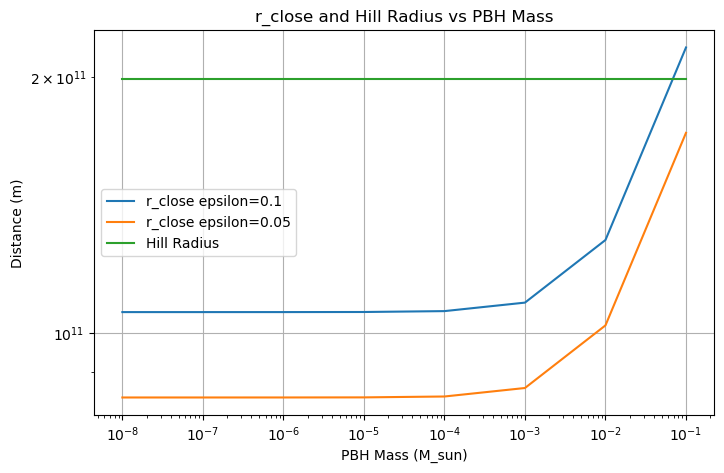

In [13]:
s = datetime.datetime.now()
G = const.G.value
name = "BetaPictoris"
v_inf_grid = np.linspace(1e3, (544e3), 20) # from 1 km/s to 800 km/s, Maximum incoming velocity v_max: 40498.00358610428
m_Sun = const.M_sun.value
m_Jup =  const.M_jup.value  # Mass of Jupiter
m_Neptune = 5.15*10**-5 * const.M_sun.value  # Mass of Neptune
m_PBH = 1e-13 * const.M_sun.value
r_SJ = (5.2*u.au).to(u.m).value
r_SN = (30.07*u.au).to(u.m).value
v_Jup = 13.06 * 1e3  # km/s to m/s
v_Neptune = 5.45 * 1e3  # km/s to m/s
epsilon = 0.1
v_inf = 20.23 * 1e3  # km/s to m/s
r_jupiter = const.R_jup.to(u.m).value
r_neptune = 24622 * 1e3  # in meters
r_sun = const.R_sun.to(u.m).value
e_jupiter = 0.0489
i_jupiter = 1.304 * (np.pi/180)
A_jupiter = np.pi * r_jupiter**2

aB = (10*u.au).to(u.m).value  # m
mA = m_Sun * 1.75
mB = m_Jup * 13
rA = 1.7 * r_sun
rB = 1.4 * r_jupiter
m_PBH = m_Sun
muA = G * mA
muB = G * mB
vBMag = np.sqrt(muA/aB)
eB = 0
rC_rH_ratio = 0.7040
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
seed = 42
system_param_dict = {
    'name': name,
    'mA': mA,
    'mB': mB,
    'mC' : m_PBH,
    'aB': aB,
    'rB': rB,
    'rA': rA,
    'vB' : vBMag,
    'eB' : 0,
    'iB' : 0,
    'epsilon': epsilon,
    'seed_base': seed,
}
safranov_number = (mB/mA) * (aB/rB)
trials = 10_000_000
sample_size = 200
lambda_limits = [0, 2*np.pi]
cosbeta_limits = [-1, 1]   # cosβ
phi_limits = [0, 2 * np.pi]
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
vesc = calc.v_esc(muA, aB)
# rclose = calc.r_close(epsilon, mA, mB, aB)
vmax = vesc + 2*vBMag
vinf_max = np.sqrt(vmax**2 - (2 * muA / aB) - (2 * muB / rclose))
print(f'orbital velocity of B: {vBMag}')
print("Escape velocity v_esc:", vesc)
print("Maximum incoming velocity v_max:", vinf_max)
T =2*np.pi*np.sqrt(aB**3/(G*(mA + mB)))
print(f'Orbital period of B: {T/(3600*24)} days')
print(f'radius of B: {rclose*u.m.to(u.au)} au')
print(f'radius of C: {calc.schwarzchild_radius(m_PBH)*u.m.to(u.au)} au')
print(rclose*u.m.to(u.au))
print(f"epsilon: {epsilon:.2e}")
print(f"r_hill: {r_hill*u.m.to(u.au)} au")
print(f" aB to rclose ratio: {aB/rclose} aB to rhill ratio: {aB/r_hill}")
print(f"safranov number {safranov_number}")
print(system_param_dict)
rc = []
rcad = []
rh = []
mPBH_grid = np.logspace(np.log10(1e-8), np.log10(1e-1), 8) * const.M_sun.value  # from 1e-10 to 1 solar mass

for mpbh in mPBH_grid:
    muA = calc.standard_gravitational_parameter(mA,mpbh)
    muB =  calc.standard_gravitational_parameter(mB, mpbh)
    print(f"mPBH: {mpbh:.2e} kg, {mpbh/const.M_sun.value:.2e} M_sun")
    rclose = calc.r_close(0.1, muA, muB, aB)
    rc.append(rclose)
    rcadj = calc.r_close(0.05, muA, muB, aB)
    rcad.append(rcadj)
    rhill = calc.hill_radius(aB, mA, mB, eB)
    rh.append(rhill)
plt.figure(figsize=(8, 5))
plt.plot(mPBH_grid/const.M_sun.value, rc, label='r_close epsilon=0.1')
plt.plot(mPBH_grid/const.M_sun.value, rcad, label='r_close epsilon=0.05')
plt.plot(mPBH_grid/const.M_sun.value, rh, label='Hill Radius')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('PBH Mass (M_sun)')
plt.ylabel('Distance (m)')
plt.title('r_close and Hill Radius vs PBH Mass')
plt.legend()
plt.grid()
plt.show()
rcbp = rc

[3.75229544 3.75218664 3.75109946 3.74030514 3.6395216  3.03272981
 2.0286773  1.67608578]


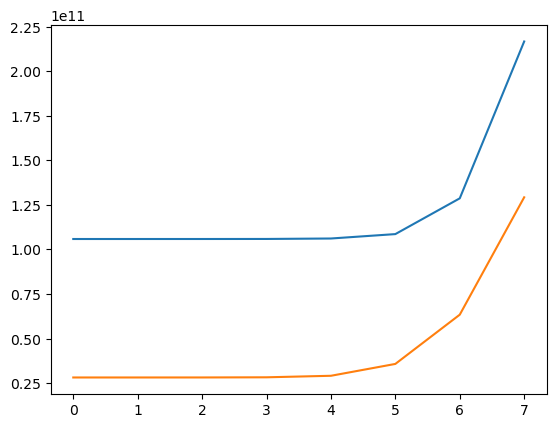

In [17]:
plt.plot(rcbp, label='Beta Pictoris')
plt.plot(rcsj, label='Sun-Jupiter')
print(np.asarray(rcbp)/np.asarray(rcsj))

orbital velocity of B: 13320.11912400804
Escape velocity v_esc: 18837.4931175974
Maximum incoming velocity v_max: 39391.58742005489
Orbital period of B: 19468.258097326536 days
radius of B: 5.487080788320946 au
radius of C: 1.9741257427538034e-08 au
5.487080788320946
epsilon: 1.06e-01
r_hill: 7.7941488470468 au
 aB to rclose ratio: 4.556156718744072 aB to rhill ratio: 3.207534329995826
safranov number 1075.1607783527384
{'name': 'SunWD', 'mA': np.float64(9.942049353490255e+30), 'mB': np.float64(9.942049353490255e+29), 'mC': np.float64(1.988409870698051e+30), 'aB': np.float64(3739946767500.0), 'rB': np.float64(347850000.0), 'vB': np.float64(13320.11912400804), 'eB': 0, 'iB': 0, 'epsilon': np.float64(0.1057314133333333), 'seed_base': 42}
mPBH: 1.99e+22 kg, 1.00e-08 M_sun
mPBH: 1.99e+23 kg, 1.00e-07 M_sun
mPBH: 1.99e+24 kg, 1.00e-06 M_sun
mPBH: 1.99e+25 kg, 1.00e-05 M_sun
mPBH: 1.99e+26 kg, 1.00e-04 M_sun
mPBH: 1.99e+27 kg, 1.00e-03 M_sun
mPBH: 1.99e+28 kg, 1.00e-02 M_sun
mPBH: 1.99e+29 k

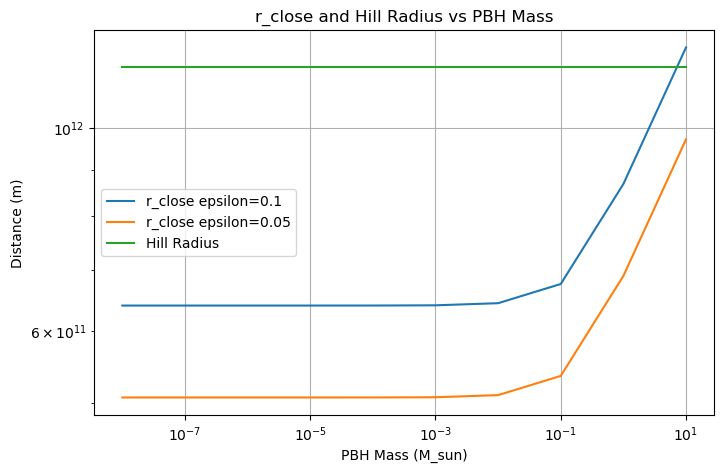

In [17]:
s = datetime.datetime.now()
G = const.G.value
name = "SunWD"
v_inf_grid = np.linspace(1e3, (544e3), 20) # from 1 km/s to 800 km/s, Maximum incoming velocity v_max: 40498.00358610428
m_Sun = const.M_sun.value
m_Jup =  const.M_jup.value  # Mass of Jupiter
m_Neptune = 5.15*10**-5 * const.M_sun.value  # Mass of Neptune
m_PBH = 1e-13 * const.M_sun.value
r_SJ = (5.2*u.au).to(u.m).value
r_SN = (30.07*u.au).to(u.m).value
v_Jup = 13.06 * 1e3  # km/s to m/s
v_Neptune = 5.45 * 1e3  # km/s to m/s
epsilon = 0.1
v_inf = 20.23 * 1e3  # km/s to m/s
r_jupiter = const.R_jup.to(u.m).value
r_neptune = 24622 * 1e3  # in meters
r_sun = const.R_sun.to(u.m).value
e_jupiter = 0.0489
i_jupiter = 1.304 * (np.pi/180)
A_jupiter = np.pi * r_jupiter**2

aB = (25*u.au).to(u.m).value  # m
mA = m_Sun * 5
mB = m_Sun * 0.5
rA = 3.4 * r_sun
rB = 0.5 * r_sun
m_PBH = m_Sun
muA = G * mA
muB = G * mB
vBMag = np.sqrt(muA/aB)
eB = 0
rC_rH_ratio = 0.7040
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
seed = 42
system_param_dict = {
    'name': name,
    'mA': mA,
    'mB': mB,
    'mC' : m_PBH,
    'aB': aB,
    'rB': rB,
    'vB' : vBMag,
    'eB' : 0,
    'iB' : 0,
    'epsilon': epsilon,
    'seed_base': seed,
}
safranov_number = (mB/mA) * (aB/rB)

trials = 10_000_000
sample_size = 200
lambda_limits = [0, 2*np.pi]
cosbeta_limits = [-1, 1]   # cosβ
phi_limits = [0, 2 * np.pi]
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
vesc = calc.v_esc(muA, aB)
# rclose = calc.r_close(epsilon, mA, mB, aB)
vmax = vesc + 2*vBMag
vinf_max = np.sqrt(vmax**2 - (2 * muA / aB) - (2 * muB / rclose))
print(f'orbital velocity of B: {vBMag}')
print("Escape velocity v_esc:", vesc)
print("Maximum incoming velocity v_max:", vinf_max)
T =2*np.pi*np.sqrt(aB**3/(G*(mA + mB)))
print(f'Orbital period of B: {T/(3600*24)} days')
print(f'radius of B: {rclose*u.m.to(u.au)} au')
print(f'radius of C: {calc.schwarzchild_radius(m_PBH)*u.m.to(u.au)} au')
print(rclose*u.m.to(u.au))
print(f"epsilon: {epsilon:.2e}")
print(f"r_hill: {r_hill*u.m.to(u.au)} au")
print(f" aB to rclose ratio: {aB/rclose} aB to rhill ratio: {aB/r_hill}")
print(f"safranov number {safranov_number}")

print(system_param_dict)
rc = []
rcad = []
rh = []
mPBH_grid = np.logspace(np.log10(1e-8), np.log10(1e1), 10) * const.M_sun.value  # from 1e-10 to 1 solar mass

for mpbh in mPBH_grid:
    muA = calc.standard_gravitational_parameter(mA,mpbh)
    muB =  calc.standard_gravitational_parameter(mB, mpbh)
    print(f"mPBH: {mpbh:.2e} kg, {mpbh/const.M_sun.value:.2e} M_sun")
    rclose = calc.r_close(0.1, muA, muB, aB)
    rc.append(rclose)
    rcadj = calc.r_close(0.05, muA, muB, aB)
    rcad.append(rcadj)
    rhill = calc.hill_radius(aB, mA, mB, eB)
    rh.append(rhill)
plt.figure(figsize=(8, 5))
plt.plot(mPBH_grid/const.M_sun.value, rc, label='r_close epsilon=0.1')
plt.plot(mPBH_grid/const.M_sun.value, rcad, label='r_close epsilon=0.05')
plt.plot(mPBH_grid/const.M_sun.value, rh, label='Hill Radius')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('PBH Mass (M_sun)')
plt.ylabel('Distance (m)')
plt.title('r_close and Hill Radius vs PBH Mass')
plt.legend()
plt.grid()
plt.show()

orbital velocity of B: 9418.7465587987
Escape velocity v_esc: 13320.11912400804
Maximum incoming velocity v_max: 27854.058586423518
Orbital period of B: 55064.54927403802 days
radius of B: 10.974161576641892 au
radius of C: 1.9741257427538034e-08 au
10.974161576641892
epsilon: 1.06e-01
r_hill: 15.5882976940936 au
 aB to rclose ratio: 4.556156718744072 aB to rhill ratio: 3.207534329995826
safranov number 2150.3215567054767
{'name': 'SunWD', 'mA': np.float64(9.942049353490255e+30), 'mB': np.float64(9.942049353490255e+29), 'mC': np.float64(1.988409870698051e+30), 'aB': np.float64(7479893535000.0), 'rB': np.float64(347850000.0), 'vB': np.float64(9418.7465587987), 'eB': 0, 'iB': 0, 'epsilon': np.float64(0.1057314133333333), 'seed_base': 42}
mPBH: 1.99e+22 kg, 1.00e-08 M_sun
mPBH: 1.99e+23 kg, 1.00e-07 M_sun
mPBH: 1.99e+24 kg, 1.00e-06 M_sun
mPBH: 1.99e+25 kg, 1.00e-05 M_sun
mPBH: 1.99e+26 kg, 1.00e-04 M_sun
mPBH: 1.99e+27 kg, 1.00e-03 M_sun
mPBH: 1.99e+28 kg, 1.00e-02 M_sun
mPBH: 1.99e+29 k

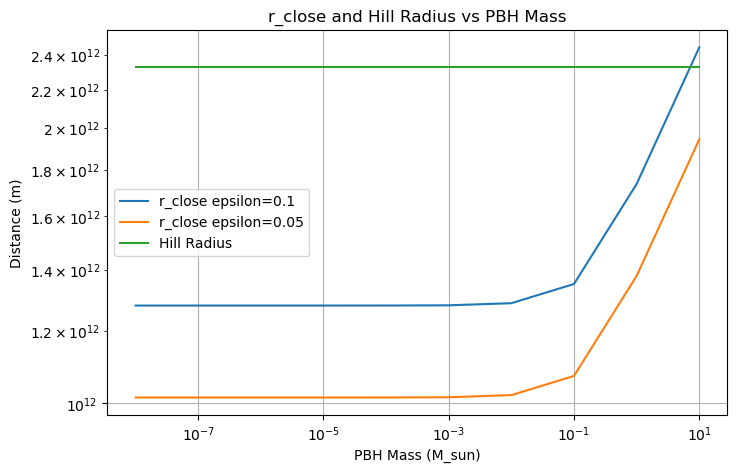

In [18]:
s = datetime.datetime.now()
G = const.G.value
name = "SunWD"
v_inf_grid = np.linspace(1e3, (544e3), 20) # from 1 km/s to 800 km/s, Maximum incoming velocity v_max: 40498.00358610428
m_Sun = const.M_sun.value
m_Jup =  const.M_jup.value  # Mass of Jupiter
m_Neptune = 5.15*10**-5 * const.M_sun.value  # Mass of Neptune
m_PBH = 1e-13 * const.M_sun.value
r_SJ = (5.2*u.au).to(u.m).value
r_SN = (30.07*u.au).to(u.m).value
v_Jup = 13.06 * 1e3  # km/s to m/s
v_Neptune = 5.45 * 1e3  # km/s to m/s
epsilon = 0.1
v_inf = 20.23 * 1e3  # km/s to m/s
r_jupiter = const.R_jup.to(u.m).value
r_neptune = 24622 * 1e3  # in meters
r_sun = const.R_sun.to(u.m).value
e_jupiter = 0.0489
i_jupiter = 1.304 * (np.pi/180)
A_jupiter = np.pi * r_jupiter**2

aB = (50*u.au).to(u.m).value  # m
mA = m_Sun * 5
mB = m_Sun * 0.5
rA = 3.4 * r_sun
rB = 0.5 * r_sun
m_PBH = m_Sun
muA = G * mA
muB = G * mB
vBMag = np.sqrt(muA/aB)
eB = 0
rC_rH_ratio = 0.7040
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
seed = 42
system_param_dict = {
    'name': name,
    'mA': mA,
    'mB': mB,
    'mC' : m_PBH,
    'aB': aB,
    'rB': rB,
    'vB' : vBMag,
    'eB' : 0,
    'iB' : 0,
    'epsilon': epsilon,
    'seed_base': seed,
}
safranov_number = (mB/mA) * (aB/rB)

trials = 10_000_000
sample_size = 200
lambda_limits = [0, 2*np.pi]
cosbeta_limits = [-1, 1]   # cosβ
phi_limits = [0, 2 * np.pi]
r_hill = calc.hill_radius(aB, mA, mB, eB)
rclose = rC_rH_ratio * r_hill 
epsilon = (rclose/aB)**3 * mA/mB
vesc = calc.v_esc(muA, aB)
# rclose = calc.r_close(epsilon, mA, mB, aB)
vmax = vesc + 2*vBMag
vinf_max = np.sqrt(vmax**2 - (2 * muA / aB) - (2 * muB / rclose))
print(f'orbital velocity of B: {vBMag}')
print("Escape velocity v_esc:", vesc)
print("Maximum incoming velocity v_max:", vinf_max)
T =2*np.pi*np.sqrt(aB**3/(G*(mA + mB)))
print(f'Orbital period of B: {T/(3600*24)} days')
print(f'radius of B: {rclose*u.m.to(u.au)} au')
print(f'radius of C: {calc.schwarzchild_radius(m_PBH)*u.m.to(u.au)} au')
print(rclose*u.m.to(u.au))
print(f"epsilon: {epsilon:.2e}")
print(f"r_hill: {r_hill*u.m.to(u.au)} au")
print(f" aB to rclose ratio: {aB/rclose} aB to rhill ratio: {aB/r_hill}")
print(f"safranov number {safranov_number}")

print(system_param_dict)
rc = []
rcad = []
rh = []
mPBH_grid = np.logspace(np.log10(1e-8), np.log10(1e1), 10) * const.M_sun.value  # from 1e-10 to 1 solar mass

for mpbh in mPBH_grid:
    muA = calc.standard_gravitational_parameter(mA,mpbh)
    muB =  calc.standard_gravitational_parameter(mB, mpbh)
    print(f"mPBH: {mpbh:.2e} kg, {mpbh/const.M_sun.value:.2e} M_sun")
    rclose = calc.r_close(0.1, muA, muB, aB)
    rc.append(rclose)
    rcadj = calc.r_close(0.05, muA, muB, aB)
    rcad.append(rcadj)
    rhill = calc.hill_radius(aB, mA, mB, eB)
    rh.append(rhill)
plt.figure(figsize=(8, 5))
plt.plot(mPBH_grid/const.M_sun.value, rc, label='r_close epsilon=0.1')
plt.plot(mPBH_grid/const.M_sun.value, rcad, label='r_close epsilon=0.05')
plt.plot(mPBH_grid/const.M_sun.value, rh, label='Hill Radius')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('PBH Mass (M_sun)')
plt.ylabel('Distance (m)')
plt.title('r_close and Hill Radius vs PBH Mass')
plt.legend()
plt.grid()
plt.show()

In [11]:
import yaml

# Define the YAML structure from current notebook variables
yaml_config = {
    'system_param_dict': {
        'mA': mA,
        'mB': mB,
        'mC': m_PBH,
        'aB': aB,
        'rB': rB,
        'rA': rA,
        'vB': vBMag,
        'eB': eB,
        'iB': 0,  # Update this value as needed
        'epsilon': epsilon,
    },
    'v_inf_grid_params': {
        'min_v': int(v_inf_grid[0]),
        'max_v': int(v_inf_grid[-1]),
        'n_v': len(v_inf_grid),
    },
    'simulation_param_dict': {
        'trials': trials,
        'max_trials': 100000000,
        'max_execution_time': 3600,
        'sample_size': sample_size,
        'max_e': 1.00,
        'vDM': 220000.0,
    }
}

# Write to YAML file
yaml_path = '/data/a.saricaoglu/repo/captus/src/ThreeBodyCapture/Configurations/SunWD.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=False, sort_keys=False)

print(f"✓ Updated {yaml_path} with current notebook values")

✓ Updated /data/a.saricaoglu/repo/captus/src/ThreeBodyCapture/Configurations/SunWD.yaml with current notebook values


In [5]:

N = trials

def mc_worker(pars):
    system_param_dict, child_ss, v_inf, trials, sample_size = pars
    rng = Generator(PCG64(child_ss)) # independent per worker
    simulation = mc_imp.MonteCarloSimulation(system_param_dict, rng)
    simulation.set_importance_sampling(quota=sample_size)
    return simulation.run_monte_carlo_simulation(trials, v_inf)

if __name__ == "__main__":

    base_ss = SeedSequence(seed)
    child_sss = base_ss.spawn(len(v_inf_grid))
    pars = [(system_param_dict, child_sss[i], v_inf_grid[i], trials, sample_size) for i in range(len(v_inf_grid))]
    # Create a pool of workers
    num_cores = len(v_inf_grid)  # Get the number of available CPU cores
    with multiprocessing.Pool(processes=num_cores) as pool:
        # Distribute the simulations across the cores
        results = pool.map(mc_worker, pars)
    pool.close()
    pool.join()

    print(f'Execution time: {datetime.datetime.now() - s} for {len(v_inf_grid)} simulations')

AttributeError: 'dict' object has no attribute 'get_system_param'

In [4]:
# Read monte carlo results and plot
import pandas as pd
import glob
import os
save_dir = f'../runs/{name}/Monte_Carlo_Results/N1e+09'
all_files = glob.glob(os.path.join(save_dir, "monte_carlo_results_*.npz"))
v_dict = {}
for file in all_files:
    data = np.load(file)
    key = int(data['v_inf']/1e3)  # convert to km/s for plotting
    print(f'v_inf = {key} km/s')
    v_dict[key] = data


v_inf = 1 km/s
v_inf = 143 km/s
v_inf = 86 km/s
v_inf = 29 km/s
v_inf = 58 km/s
v_inf = 115 km/s
v_inf = 172 km/s
v_inf = 201 km/s
v_inf = 229 km/s
v_inf = 258 km/s
v_inf = 286 km/s
v_inf = 315 km/s
v_inf = 343 km/s
v_inf = 372 km/s
v_inf = 401 km/s
v_inf = 429 km/s
v_inf = 458 km/s
v_inf = 486 km/s
v_inf = 515 km/s
v_inf = 544 km/s


{121: NpzFile '../runs/IntBH_Star/Monte_Carlo_Results/N1e+09/monte_carlo_results_v121.7_s42.npz' with keys: v_inf, n_captured, sigma_MC_m2, sigma_MC_areaB, a_au..., 182: NpzFile '../runs/IntBH_Star/Monte_Carlo_Results/N1e+09/monte_carlo_results_v182.0_s42.npz' with keys: v_inf, n_captured, sigma_MC_m2, sigma_MC_areaB, a_au..., 1: NpzFile '../runs/IntBH_Star/Monte_Carlo_Results/N1e+09/monte_carlo_results_v1.0_s42.npz' with keys: v_inf, n_captured, sigma_MC_m2, sigma_MC_areaB, a_au..., 242: NpzFile '../runs/IntBH_Star/Monte_Carlo_Results/N1e+09/monte_carlo_results_v242.3_s42.npz' with keys: v_inf, n_captured, sigma_MC_m2, sigma_MC_areaB, a_au..., 61: NpzFile '../runs/IntBH_Star/Monte_Carlo_Results/N1e+09/monte_carlo_results_v61.3_s42.npz' with keys: v_inf, n_captured, sigma_MC_m2, sigma_MC_areaB, a_au..., 302: NpzFile '../runs/IntBH_Star/Monte_Carlo_Results/N1e+09/monte_carlo_results_v302.7_s42.npz' with keys: v_inf, n_captured, sigma_MC_m2, sigma_MC_areaB, a_au..., 363: NpzFile '../runs

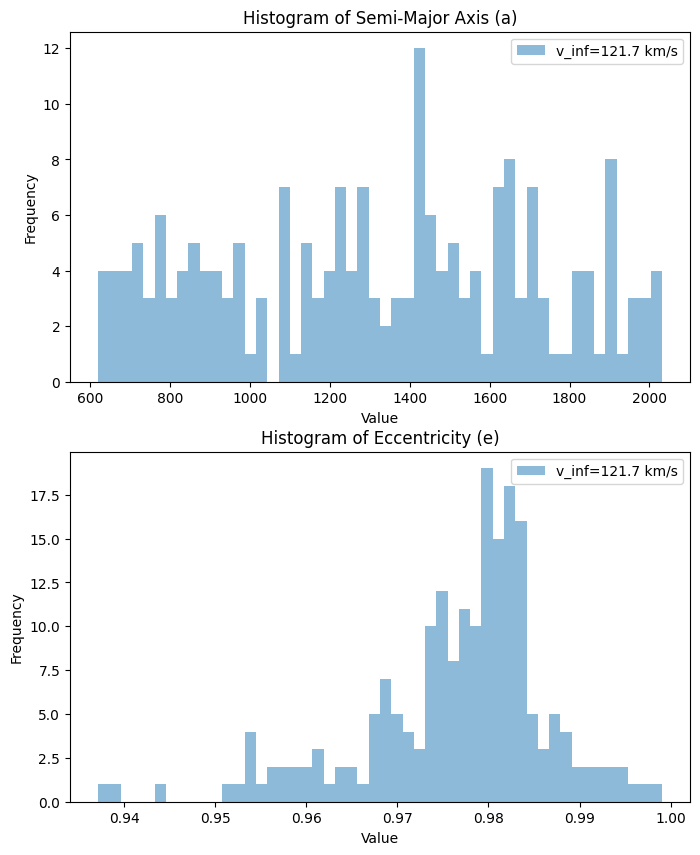

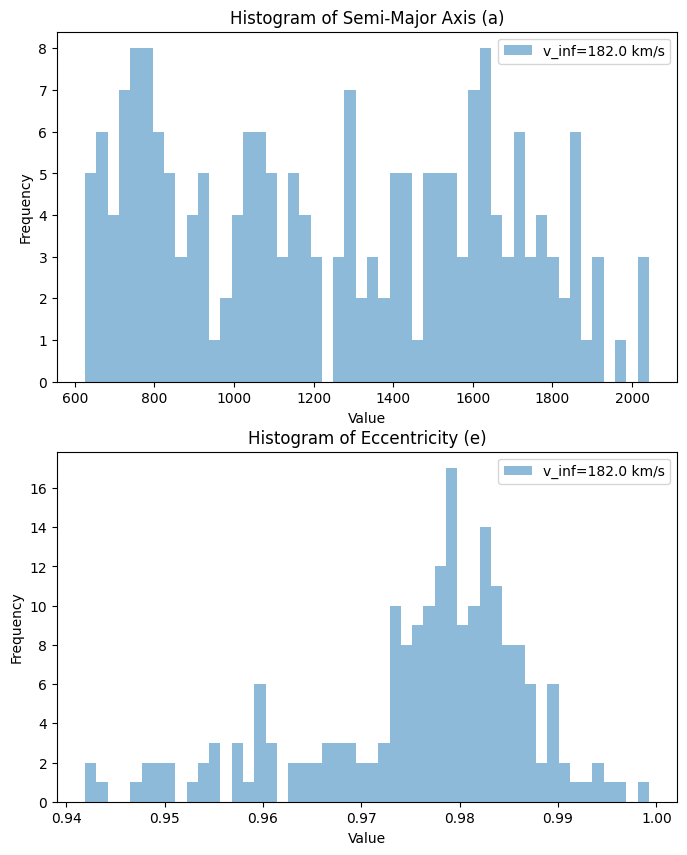

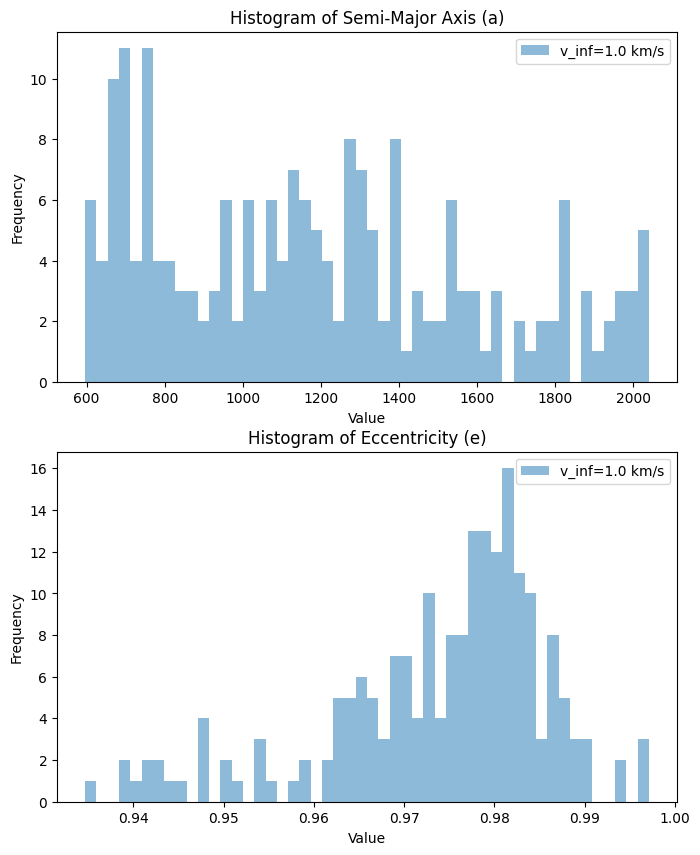

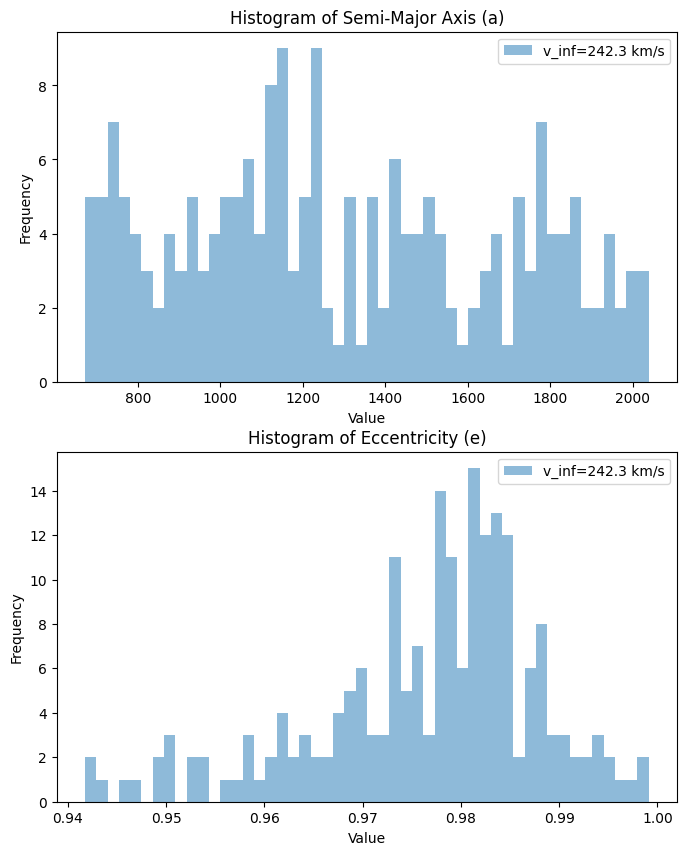

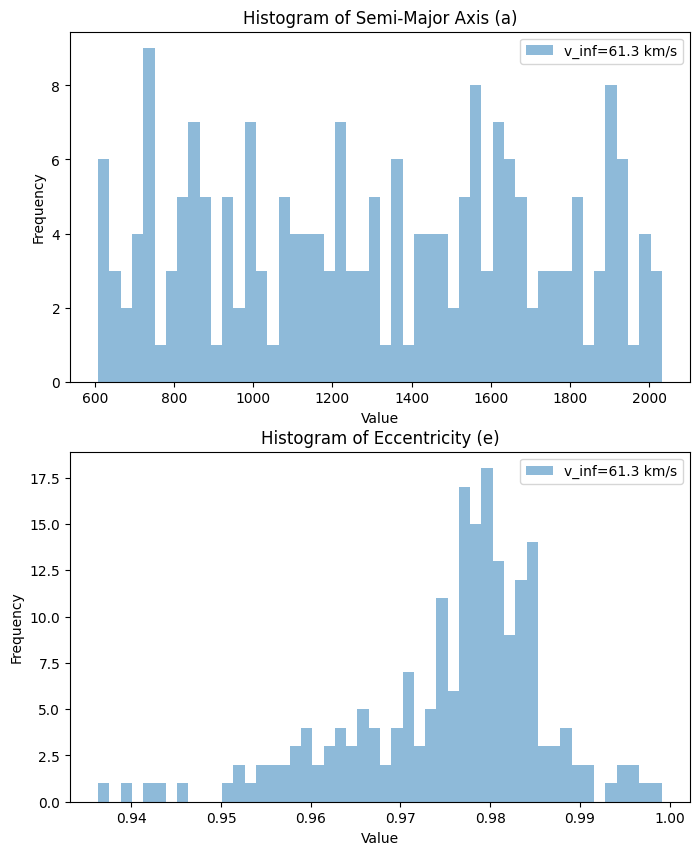

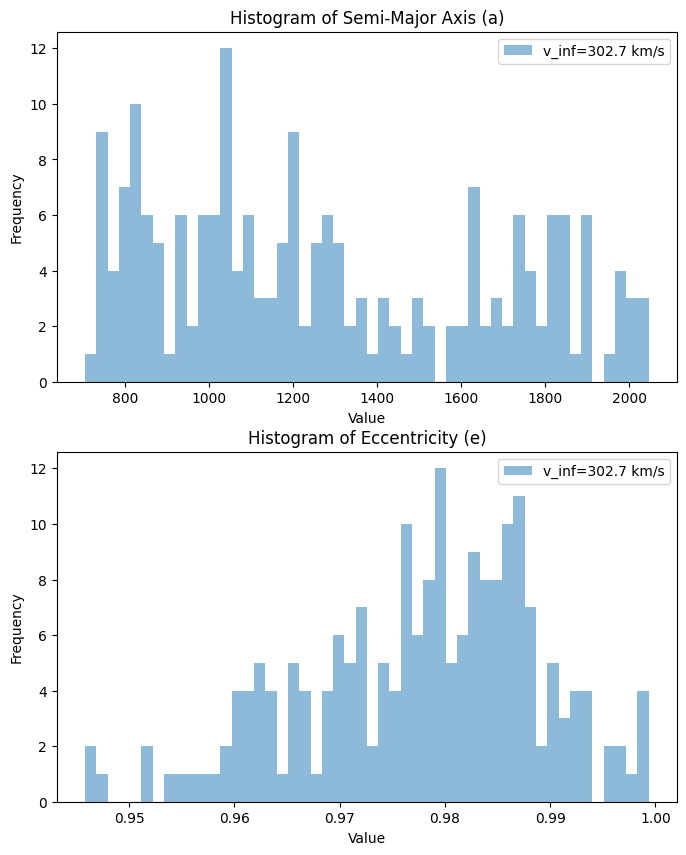

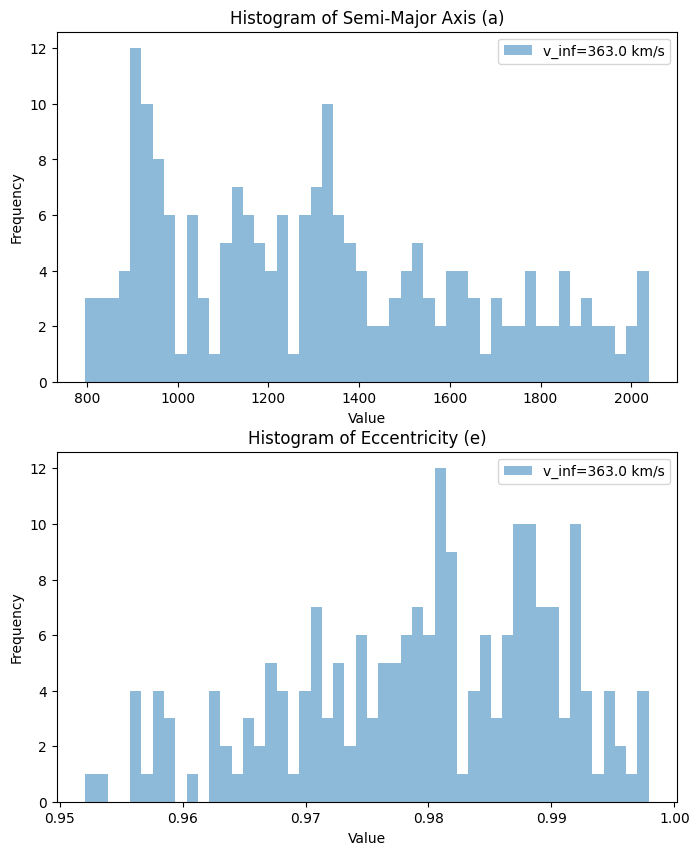

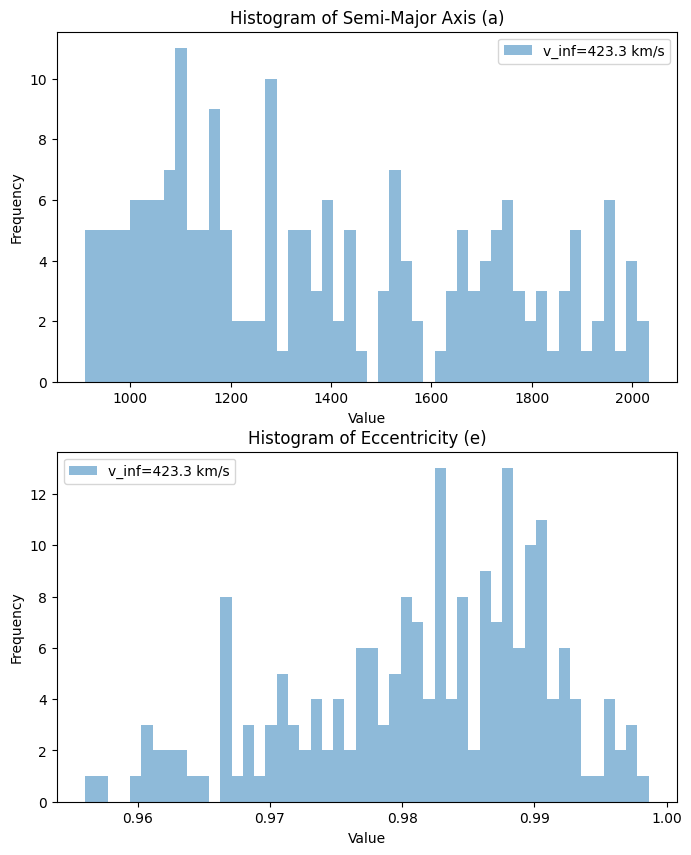

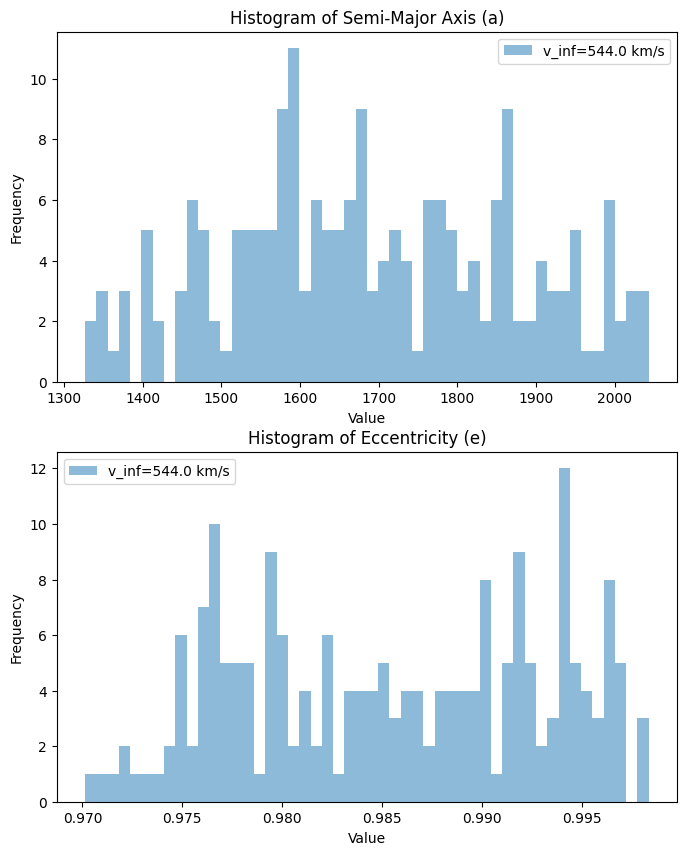

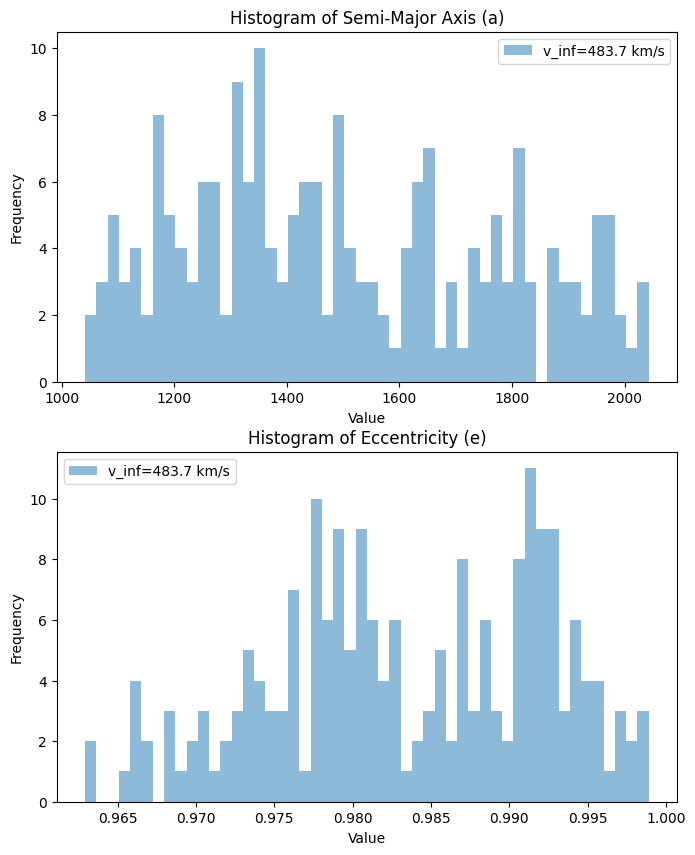

In [55]:
print(v_dict)  # Print the first DataFrame to verify loading
for v in v_dict.keys():
    data = v_dict[v]
    a_vals = data['a_au']
    e_vals = data['e']
    v_inf = data['v_inf']
    fig, ax = plt.subplots(2, 1, figsize=(8, 10))
    ax[0].hist(a_vals, bins=50, alpha=0.5, label=f'v_inf={v_inf/1e3:.1f} km/s')
    ax[1].hist(e_vals, bins=50, alpha=0.5, label=f'v_inf={v_inf/1e3:.1f} km/s')
    ax[0].set_xlabel('Value')
    ax[0].set_ylabel('Frequency')
    ax[0].set_title('Histogram of Semi-Major Axis (a)')
    ax[1].set_xlabel('Value')
    ax[1].set_ylabel('Frequency')
    ax[1].set_title('Histogram of Eccentricity (e)')
    ax[0].legend()
    ax[1].legend()
    plt.show()

In [5]:
for v in v_dict.keys():
    data = v_dict[v]
    a_vals = data['a_au']
    n_captured = data['n_captured']
    print(f'captured objects for v_inf = {v} km/s: {data['n_captured']}')
    if n_captured < 100 and n_captured > 0:
        
        continue
    a_vals_mean = np.mean(a_vals)
    a_vals_std = np.std(a_vals)
    sample_from_a_vals = np.random.choice(a_vals, size=100, replace=False)
    sampled_a_mean = np.mean(sample_from_a_vals)
    sampled_a_std = np.std(sample_from_a_vals)
    # print(f'v_inf = {v} km/s: original population size = {len(a_vals)} a mean = {a_vals_mean:.3f} au, a std = {a_vals_std:.3f} au; sampled a mean = {sampled_a_mean:.3f} au, sampled a std = {sampled_a_std:.3f} au')
    print(f'v_inf = {v} km/s: a_mean - sampled_a_mean = {a_vals_mean - sampled_a_mean:.3f} au, a_std - sampled_a_std = {a_vals_std - sampled_a_std:.3f} au')

captured objects for v_inf = 1 km/s: 200
v_inf = 1 km/s: a_mean - sampled_a_mean = -45.072 au, a_std - sampled_a_std = -12.734 au
captured objects for v_inf = 143 km/s: 200
v_inf = 143 km/s: a_mean - sampled_a_mean = 29.729 au, a_std - sampled_a_std = 3.764 au
captured objects for v_inf = 86 km/s: 200
v_inf = 86 km/s: a_mean - sampled_a_mean = -36.516 au, a_std - sampled_a_std = 11.038 au
captured objects for v_inf = 29 km/s: 200
v_inf = 29 km/s: a_mean - sampled_a_mean = -6.403 au, a_std - sampled_a_std = -18.668 au
captured objects for v_inf = 58 km/s: 200
v_inf = 58 km/s: a_mean - sampled_a_mean = 39.913 au, a_std - sampled_a_std = -8.500 au
captured objects for v_inf = 115 km/s: 200
v_inf = 115 km/s: a_mean - sampled_a_mean = 14.121 au, a_std - sampled_a_std = 5.638 au
captured objects for v_inf = 172 km/s: 200
v_inf = 172 km/s: a_mean - sampled_a_mean = 20.927 au, a_std - sampled_a_std = 9.419 au
captured objects for v_inf = 201 km/s: 200
v_inf = 201 km/s: a_mean - sampled_a_mean 

v_inf = 17 km/s: a_mean - sampled_a_mean = -0.196 au, a_std - sampled_a_std = -0.434 au
v_inf = 11 km/s: a_mean - sampled_a_mean = 1.307 au, a_std - sampled_a_std = 1.738 au
v_inf = 22 km/s: a_mean - sampled_a_mean = -0.935 au, a_std - sampled_a_std = -1.435 au
v_inf = 6 km/s: a_mean - sampled_a_mean = 2.585 au, a_std - sampled_a_std = 1.389 au
v_inf = 1 km/s: a_mean - sampled_a_mean = -1.616 au, a_std - sampled_a_std = 2.398 au

In [6]:
if 'rng' not in locals():
    rng = np.random.default_rng(seed)

sampled_v_dict = {}
for v in v_dict.keys():
    data = v_dict[v]  # npz file handle
    n_captured = int(data['n_captured'])
    if n_captured == 0:
        continue

    # Arrays of per-capture parameters saved by MC
    a_au = data['a_au']            # shape (n_captured,)
    e_arr = data['e']              # shape (n_captured,)
    cap_lambda = data['cap_lambda']# shape (n_captured,)
    cap_beta = data['cap_beta']    # shape (n_captured,)
    cap_b = data['cap_b']          # shape (n_captured,) in meters
    cap_phi = data['cap_phi']      # shape (n_captured,)

    # Sanity: all arrays must have length n_captured
    assert len(a_au) == len(e_arr) == len(cap_lambda) == len(cap_beta) == len(cap_b) == len(cap_phi) == n_captured

    # Choose indices
    if n_captured <= sample_size:
        idx = np.arange(n_captured)
    else:
        idx = rng.choice(n_captured, size=sample_size, replace=False)

    # Slice consistently
    sampled_v_dict[v] = {
        'v_inf': float(data['v_inf']),             # m/s
        'a_au': a_au[idx],
        'e': e_arr[idx],
        'lambda1': cap_lambda[idx],
        'beta': cap_beta[idx],
        'b': cap_b[idx],                         # meters (convert in OrbitalSimulation)
        'phi': cap_phi[idx],
        'n_sampled': len(idx),
    }

In [7]:
def rebound_worker(pars):
    system_param_dict, child_ss, i, v_inf, lambda1, beta, phi, b, a_c, e_c = pars
    rng = Generator(PCG64(child_ss))  # independent per worker
    simulation = OrbitalSimulation(system_param_dict, rng)
    return simulation.run_orbital_integration(i, v_inf, lambda1, beta, phi, b, a_c, e_c)

if __name__ == "__main__":
    # Build a single flat list of tasks and run pool.map once.
    num_cores = 30  # limit workers (or use multiprocessing.cpu_count())
    total_jobs = np.sum([vdata['n_sampled'] for vdata in sampled_v_dict.values()])

    base_ss = SeedSequence(seed)
    child_sss = base_ss.spawn(int(total_jobs))  # one child seed per job

    pars = []
    job_idx = 0
    for j, (v_key, vdata) in enumerate(sampled_v_dict.items()):
        v_inf = vdata['v_inf']
        lambda1 = vdata['lambda1']
        beta = vdata['beta']
        b = vdata['b']
        phi = vdata['phi']
        a_c = vdata['a_au']
        e_c = vdata['e']

        # Create a task per sampled capture for this v_inf
        for i in range(vdata['n_sampled']):
            pars.append((
                system_param_dict,
                child_sss[job_idx],  # simple monotonic index across all jobs
                i, v_inf, lambda1[i], beta[i], phi[i], b[i], a_c[i], e_c[i]
            ))
            job_idx += 1

    # Dispatch all jobs once, avoid pool inside the loop
    with multiprocessing.Pool(processes=num_cores) as pool:
        results = pool.map(rebound_worker, pars)

    print(f'Execution time: {datetime.datetime.now() - s} for {job_idx} simulations')

Simulation 34 of starting at 2025-12-19 22:32:06.866420Simulation 0 of starting at 2025-12-19 22:32:06.866218Simulation 68 of starting at 2025-12-19 22:32:06.867019Simulation 102 of starting at 2025-12-19 22:32:06.867574
Simulation 136 of starting at 2025-12-19 22:32:06.867853

Simulation 170 of starting at 2025-12-19 22:32:06.868370

Simulation 4 of starting at 2025-12-19 22:32:06.868961

Simulation 106 of starting at 2025-12-19 22:32:06.869954Simulation 140 of starting at 2025-12-19 22:32:06.870496

Simulation 42 of starting at 2025-12-19 22:32:06.871784Simulation 174 of starting at 2025-12-19 22:32:06.871436Simulation 8 of starting at 2025-12-19 22:32:06.871818Simulation 76 of starting at 2025-12-19 22:32:06.872226Simulation 110 of starting at 2025-12-19 22:32:06.872775

Simulation 144 of starting at 2025-12-19 22:32:06.873068

Simulation 178 of starting at 2025-12-19 22:32:06.873540
Simulation 12 of starting at 2025-12-19 22:32:06.873987


Simulation 46 of starting at 2025-12-19 22

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Error during integration: Particle C is free: E_c:  558.5487366566667, rAC: 37.36704513106762, Simulation failed for system 23, at time 186404.5943620552. Script continues...
Simulation 23  completed at 2025-12-20 00:47:29.807140
Simulation 24 of starting at 2025-12-20 00:47:29.822662
Error during integration: Two particles collided (d < r1+r2), Simulation failed for system 65, at time 17384.570882794847. Script continues...
Simulation 65  completed at 2025-12-20 00:47:33.371188
Simulation 66 of starting at 2025-12-20 00:47:33.373683
Error during integration: Two particles collided (d < r1+r2), Simulation failed for system 66, at time 2743.2037642373293. Script continues...
Simulation 66  completed at 2025-12-20 00:47:36.961198
Simulation 67 of starting at 2025-12-20 00:47:36.965292
Error during integration: Two particles collided (d < r1+r2), Simulation failed for system 17, at time 110961.37917287197. Script continues...
Simulation 17  completed at 2025-12-20 00:47:52.755458
Simulati

In [ ]:
import rebound
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')
G_unit = sim.G
print(G_unit)
G_MsunAuYr = const.G.to(u.au**3 / (u.Msun * u.yr**2)).value
print(G_MsunAuYr)

39.476926421373
39.476926408897626


In [5]:
# read from saved npz files and aggregate results
all_lifetimes = []
all_eccentricities = []
all_semi_major_axes = []
alltimes = []
ids = []
for filename in os.listdir(f'/data/a.saricaoglu/repo/captus/runs/{name}/Rebound_Simulation_Results'):
    if filename.endswith(".npz"):
        data = np.load(os.path.join(f'/data/a.saricaoglu/repo/captus/runs/{name}/Rebound_Simulation_Results', filename), allow_pickle=True)
        sys_id = data['i']
        ids.append(sys_id)
        all_lifetimes.append((sys_id, data['lifetime'], data['final_energy_c'], data['termination_flag']))
        all_eccentricities.append((sys_id, data['eccentricities']))
        all_semi_major_axes.append((sys_id, data['semi_major_axes']))   
        alltimes.append((sys_id, data['times'])) 
        start_info = data['start_info']
        start_distances = data['start_distances']
        errors = data['errors']
        print(f"Loaded data from {filename}: {start_info}, {start_distances}, {errors}")
print("Aggregated Lifetimes:", all_lifetimes)
print("Aggregated Eccentricities:", all_eccentricities)
print("Aggregated SemiMajorAxes:", all_semi_major_axes)

# Produce the same plots as above for aggregated data
sys1_aggr = all_semi_major_axes[0][1]
sys1_ecc_aggr = all_eccentricities[0][1]

plt.figure(figsize=(12, 6))
plt.hist(sys1_aggr, density=True, bins=50, color='green', alpha=0.7)
plt.xlabel('Semi-major axis a (AU)')
plt.yscale('log')
plt.ylabel('Number of captured orbits')
plt.title('Histogram of Captured PBH Semi-Major Axes from Aggregated Data')
plt.grid()
plt.show()
plt.figure(figsize=(12, 6))
plt.hist(sys1_ecc_aggr, density=True, bins=50, color='green', alpha=0.7)
plt.xlabel('Eccentricity e')
plt.ylabel('Number of captured orbits')
plt.title('Histogram of Captured PBH Eccentricities from Aggregated Data')
plt.grid()
plt.show()

# sys2_aggr = all_semi_major_axes[1][1]
# sys2_ecc_aggr = all_eccentricities[1][1]

# plt.figure(figsize=(12, 6))
# plt.hist(sys2_aggr, density=True, bins=50, color='red', alpha=0.7)
# plt.xlabel('Semi-major axis a (AU)')
# plt.yscale('log')
# plt.ylabel('Number of captured orbits')
# plt.title('Histogram of Captured PBH Semi-Major Axes from Aggregated Data (System 2)')
# plt.grid()
# plt.show()
# plt.figure(figsize=(12, 6))
# plt.hist(sys2_ecc_aggr, density=True, bins=50, color='red', alpha=0.7)
# plt.xlabel('Eccentricity e')
# plt.ylabel('Number of captured orbits')
# plt.title('Histogram of Captured PBH Eccentricities from Aggregated Data (System 2)')
# plt.grid()
# plt.show()

# now time evolution plots for aggregated data

sys1_lifetime_aggr = all_lifetimes[0][1]
fig, ax = plt.subplots(2, 1, figsize=(7, 3.5), sharex=True)
# time_steps_aggr = np.arange(len(sys1_aggr)) * (sys1_lifetime_aggr / len(sys1_aggr))
ax[0].plot(alltimes[0][1], sys1_aggr, label='Semi-Major Axis (AU)')
ax[1].plot(alltimes[0][1], sys1_ecc_aggr, label='Eccentricity')
ax[1].set_xlabel('Time (years)')
ax[0].set_ylabel('Semi-Major Axis (AU)')
ax[1].set_ylabel('Eccentricity')
plt.title('Time Evolution of Semi-Major Axis and Eccentricity from Aggregated Data')
plt.legend()
plt.show()

# sys2_lifetime_aggr = all_lifetimes[1][1]
# fig, ax = plt.subplots(2, 1, figsize=(7, 3.5), sharex=True)
# time_steps_aggr2 = np.arange(len(sys2_aggr)) * (sys2_lifetime_aggr / len(sys2_aggr))
# ax[0].plot(time_steps_aggr2, sys2_aggr, label='Semi-Major Axis (AU)')       
# ax[1].plot(time_steps_aggr2, sys2_ecc_aggr, label='Eccentricity')
# ax[1].set_xlabel('Time (years)')
# ax[0].set_ylabel('Semi-Major Axis (AU)')
# ax[1].set_ylabel('Eccentricity')
# plt.title('Time Evolution of Semi-Major Axis and Eccentricity from Aggregated Data (System 2)')
# plt.legend()
# plt.show()


Aggregated Lifetimes: []
Aggregated Eccentricities: []
Aggregated SemiMajorAxes: []


IndexError: list index out of range

In [6]:
# ...existing code...
import os, glob, numpy as np

base_dir = f"/data/a.saricaoglu/repo/captus/runs/{name}/Rebound_Simulation_Results"
mc_dir   = f"/data/a.saricaoglu/repo/captus/runs/{name}/Monte_Carlo_Results/N1e+09"
os.makedirs(f"../plots/{name}", exist_ok=True)
def vkey_from_vinf(v_inf_mps: float) -> str:
    # km/s rounded to nearest integer, prefixed with 'v'
    return f"v{int(np.rint(v_inf_mps/1e3))}"

# 1) Index MC files by vX
mc_by_vkey = {}
for mc_path in glob.glob(os.path.join(mc_dir, "monte_carlo_results_*.npz")):
    try:
        with np.load(mc_path, allow_pickle=True) as mc_probe:
            v_inf = float(mc_probe["v_inf"])
        vk = vkey_from_vinf(v_inf)
        # keep the handle open for later reads (consistent with rest of notebook)
        mc_by_vkey[vk] = {
            "path": mc_path,
            "v_key": vk,
            "v_inf": v_inf,
            "data": np.load(mc_path, allow_pickle=True),
        }
    except Exception as e:
        print(f"Failed to index MC {mc_path}: {e}")

# 2) Index Rebound Simulation files by vX subfolder
rebound_by_vkey = {}
for v_folder in sorted(os.listdir(base_dir)):
    if not (v_folder.startswith("v") and os.path.isdir(os.path.join(base_dir, v_folder))):
        continue
    v_path = os.path.join(base_dir, v_folder)
    entries = []

    for f in sorted(glob.glob(os.path.join(v_path, "*.npz"))):
        try:
            data = np.load(f, allow_pickle=True)
            sys_id = int(data["i"]) if "i" in data.files else os.path.splitext(os.path.basename(f))[0]
            entries.append({
                "path": f,
                "i": sys_id,
                "data": data,
            })
        except Exception as e:
            print(f"Failed to load Rebound {f}: {e}")
    rebound_by_vkey[v_folder] = entries

# 3) Combine into a single catalog keyed by vX (union of keys)
all_keys = sorted(set(mc_by_vkey.keys()) | set(rebound_by_vkey.keys()))
catalog = {}
for vk in all_keys:
    catalog[vk] = {
        "mc": mc_by_vkey.get(vk),                # dict or None
        "rebound": rebound_by_vkey.get(vk, []),  # list (possibly empty)
    }

print("Catalog summary:")
for k in all_keys:
    mc_ok = "yes" if catalog[k]["mc"] else "no"
    n_rb = len(catalog[k]["rebound"])
    print(f"  {k}: MC={mc_ok}, Rebound files={n_rb}")

# Optional convenience views:
per_v_semi_major_axes = {
    k: [e["data"]["semi_major_axes"] for e in catalog[k]["rebound"] if "semi_major_axes" in e["data"].files]
    for k in catalog.keys()
}
per_v_lifetimes = {
    k: [e["data"]["lifetime"] for e in catalog[k]["rebound"] if "lifetime" in e["data"].files]
    for k in catalog.keys()
}
# ...existing code...

Catalog summary:
  v1: MC=yes, Rebound files=200
  v115: MC=yes, Rebound files=200
  v144: MC=yes, Rebound files=200
  v172: MC=yes, Rebound files=200
  v201: MC=yes, Rebound files=200
  v230: MC=yes, Rebound files=200
  v258: MC=yes, Rebound files=200
  v287: MC=yes, Rebound files=200
  v30: MC=yes, Rebound files=200
  v315: MC=yes, Rebound files=200
  v344: MC=yes, Rebound files=200
  v373: MC=yes, Rebound files=200
  v401: MC=yes, Rebound files=200
  v430: MC=yes, Rebound files=200
  v458: MC=yes, Rebound files=200
  v487: MC=yes, Rebound files=200
  v515: MC=yes, Rebound files=200
  v544: MC=yes, Rebound files=200
  v58: MC=yes, Rebound files=200
  v87: MC=yes, Rebound files=200


In [24]:
print(mA/m_Sun, mB/m_Sun, aB/u.au)

360000.00000000006 110.0 5983914828000.0 1 / AU


In [7]:
vdm = (220*u.km/u.s).to(u.au/u.yr).value  # m/s

termination_flags = {}
for v in catalog.keys():
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]
    # Skip if no MC data
    if mc_data is None:
        continue
    print(f"Start info for {v}:")
    start_info = [orbsim_data["data"]["start_info"] for orbsim_data in catalog[v]["rebound"] if "start_info" in orbsim_data["data"].files]
    start_distances = [orbsim_data["data"]["start_distances"] for orbsim_data in catalog[v]["rebound"] if "start_distances" in orbsim_data["data"].files]
    errors = [orbsim_data["data"]["errors"] for orbsim_data in catalog[v]["rebound"] if "errors" in orbsim_data["data"].files]
    flags = [orbsim_data["data"]["termination_flag"] for orbsim_data in catalog[v]["rebound"] if "termination_flag" in orbsim_data["data"].files]
    lifetimes = [orbsim_data["data"]["lifetime"] for orbsim_data in catalog[v]["rebound"] if "lifetime" in orbsim_data["data"].files]
    print()
    b_err_count = 0
    P_err_count = 0
    time_err_count = 0
    escape_C_count = 0
    escape_B_count = 0
    energy_err_count = 0
    preprocess_err_count = 0
    time_exceeded_count = 0
    collision_count = 0
    ej_mask = []
    coll_mask = []
    for idx, (sinfo, sdist, err, flag, lifetime) in enumerate(zip(start_info, start_distances, errors, flags, lifetimes)):
        # print(f"  Simulation {idx}: start_info={sinfo}")
        # print(f"  Simulation {idx}: start_distances={sdist}")

        if len(err) > 0:

            if 'impact parameter b' in err[0]:
                b_err_count += 1
                
            if 'period' in err[0]:
                P_err_count += 1
                # print(f"  Simulation {idx}: errors={err}")
                # print(f"  Simulation {idx}: start_info={sinfo}")
            if 'time' in err[0]:
                time_err_count += 1

            if flag == None:
                preprocess_err_count += 1
                coll_mask.append(0)
        else:
            if flag == None:
                collision_count += 1
                coll_mask.append(1)
            else:
                coll_mask.append(0)
   
        if 'escape_C' in flag:
            escape_C_count += 1
            ej_mask.append(1)
        else:
            ej_mask.append(0)
            
        if 'escape_B' in flag:
            escape_B_count += 1
        if 'energy' in flag:
            energy_err_count += 1

        if 'time_exceeded' in flag:
            time_exceeded_count += 1

    catalog[v]['termination_flags'] = {
        "b_err_count": b_err_count,
        "P_err_count": P_err_count,
        "time_err_count": time_err_count,
        "escape_C_count": escape_C_count,
        "escape_B_count": escape_B_count,
        "energy_err_count": energy_err_count,
        "preprocess_err_count": preprocess_err_count,
        "time_exceeded_count": time_exceeded_count,
        "collision_count": collision_count,
    }
    catalog[v]['ej_mask'] = ej_mask
    catalog[v]['coll_mask'] = coll_mask
    
    print(f"Total simulations for {v} with impact parameter b errors: {b_err_count}")
    print(f"Total simulations for {v} with period errors: {P_err_count}")
    print(f"Total simulations for {v} with time errors: {time_err_count}")
    print(f"Total simulations for {v} with escape C flag: {escape_C_count}")
    print(f"Total simulations for {v} with escape B flag: {escape_B_count}")
    print(f"Total simulations for {v} with energy flag: {energy_err_count}")
    print(f"Total simulations for {v} with preprocess errors: {preprocess_err_count}")
    print(f"Total simulations for {v} with time exceeded flags: {time_exceeded_count}")
    print(f"Total simulations for {v} with collision flags: {collision_count}")

Start info for v1:

Total simulations for v1 with impact parameter b errors: 9
Total simulations for v1 with period errors: 0
Total simulations for v1 with time errors: 0
Total simulations for v1 with escape C flag: 105
Total simulations for v1 with escape B flag: 0
Total simulations for v1 with energy flag: 0
Total simulations for v1 with preprocess errors: 4
Total simulations for v1 with time exceeded flags: 1
Total simulations for v1 with collision flags: 90
Start info for v115:

Total simulations for v115 with impact parameter b errors: 10
Total simulations for v115 with period errors: 0
Total simulations for v115 with time errors: 0
Total simulations for v115 with escape C flag: 93
Total simulations for v115 with escape B flag: 0
Total simulations for v115 with energy flag: 0
Total simulations for v115 with preprocess errors: 6
Total simulations for v115 with time exceeded flags: 2
Total simulations for v115 with collision flags: 99
Start info for v144:

Total simulations for v144

In [8]:
occurrences = {}
for v in catalog.keys():
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]
    ej_mask = catalog[v]['ej_mask']
    print(f'ejected C count for {v}: {np.sum(ej_mask)}')
    coll_mask = catalog[v]['coll_mask']
    print(f'collision count for {v}: {np.sum(coll_mask)}')
    preprocess_err_count = catalog[v]['termination_flags']['preprocess_err_count']
    print(f'preprocess error count for {v}: {preprocess_err_count}')
    time_exceeded_count = catalog[v]['termination_flags']['time_exceeded_count']
    print(f'time exceeded count for {v}: {time_exceeded_count}')
    print(orbsim_data)
    # Skip if no MC data
    if mc_data is None:
        continue

    vinfinity = (mc_data["v_inf"]*u.m/u.s).to(u.au/u.yr).value
    mc_pkg = mc_data["data"]
    n_captured = int(mc_pkg["n_captured"])
    capture_cross_section = (mc_pkg["sigma_MC_m2"] * u.m**2).to(u.au**2).value
    lifetimes = [e["data"]["lifetime"] for e in orbsim_data if "lifetime" in e["data"].files]
    ejected_lifetimes = [l for l, ej in zip(lifetimes, ej_mask) if ej == 1]
    collided_lifetimes = [l for l, coll in zip(lifetimes, coll_mask) if coll == 1]

    ejection_rate = len([l for l in ejected_lifetimes if l is not None]) / np.sum([l for l in ejected_lifetimes if l is not None])
    collision_rate = len([l for l in collided_lifetimes if l is not None]) / np.sum([l for l in collided_lifetimes if l is not None])
    termination_rate = ejection_rate + collision_rate  # total removal rate
    f_approx = (np.sqrt(2/np.pi)) * (vinfinity**2 / (vdm**3)) * np.exp(- (vinfinity)**2/(2*vdm**2))
    print(f'v_inf = {mc_pkg["v_inf"]/1e3} km/s: captured = {n_captured}, capture cross-section = {capture_cross_section:.3e} au^2, ejection rate = {ejection_rate:.3e} 1/Myr')
    total_rate = len(lifetimes) / np.sum(lifetimes )

    rClose = calc.r_close(epsilon, mA, mB, aB)
    v1Mag = calc.v_1_mag(mc_data["v_inf"], muA, muB, aB, rClose)
    v1Mag_au = v1Mag * (u.m / u.s).to(u.au/u.yr) # convert to au/yr

    n_eq_ejection = f_approx * capture_cross_section * v1Mag_au / ejection_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s: {n_eq_ejection:.3e}')
    n_eq_collision = f_approx * capture_cross_section * v1Mag_au / collision_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s (collision): {n_eq_collision:.3e}')
    n_eq = f_approx * capture_cross_section * v1Mag_au / termination_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s (total): {n_eq:.3e}')
    n_eq_total = f_approx * capture_cross_section * v1Mag_au / total_rate  # captures per au
    print(f'Estimated number of captures at v_inf = {mc_pkg["v_inf"]/1e3} km/s (all removals): {n_eq_total:.3e}')
    occurrences[v] = {
        "n_captured": n_captured,
        "capture_cross_section_au": capture_cross_section,
        "capture_cross_section_areaB": mc_pkg["sigma_MC_areaB"],
        "ejection_rate_1_per_yr": ejection_rate,
        "collision_rate_1_per_yr": collision_rate,
        "termination_rate_1_per_yr": termination_rate,
        "total_rate_1_per_yr": total_rate,
        "total_systems_in_equilibrium": n_eq,
        "ejected_systems_in_equilibrium": n_eq_ejection,
        "collided_systems_in_equilibrium": n_eq_collision,
        "total_systems_in_equilibrium_all_removals": n_eq_total,

    }


ejected C count for v1: 105
collision count for v1: 90
preprocess error count for v1: 4
time exceeded count for v1: 1
[{'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_0_42.npz', 'i': 0, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_0_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_100_42.npz', 'i': 100, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_100_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_101_42.npz', 'i': 101, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_101_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/

In [168]:
n_eq_ejection = sum([occurrences[v]['ejected_systems_in_equilibrium'] for v in occurrences.keys() if occurrences[v]['ejected_systems_in_equilibrium'] > 0])
n_eq_collision = sum([occurrences[v]['collided_systems_in_equilibrium'] for v in occurrences.keys() if occurrences[v]['collided_systems_in_equilibrium'] > 0])
n_eq_termination = sum([occurrences[v]['total_systems_in_equilibrium'] for v in occurrences.keys() if occurrences[v]['total_systems_in_equilibrium'] > 0])
n_eq_total = sum([occurrences[v]['total_systems_in_equilibrium_all_removals'] for v in occurrences.keys() if occurrences[v]['total_systems_in_equilibrium_all_removals'] > 0])
print(f'Total estimated number of captured PBHs in equilibrium (ejection only): {n_eq_ejection:.3e}')
print(f'Total estimated number of captured PBHs in equilibrium (collision only): {n_eq_collision:.3e}')
print(f'Total estimated number of captured PBHs in equilibrium (total): {n_eq_termination:.3e}')
print(f'Total estimated number of captured PBHs in equilibrium (all removals): {n_eq_total:.3e}')

Total estimated number of captured PBHs in equilibrium (ejection only): 1.153e+07
Total estimated number of captured PBHs in equilibrium (collision only): 8.617e+06
Total estimated number of captured PBHs in equilibrium (total): 4.858e+06
Total estimated number of captured PBHs in equilibrium (all removals): 9.327e+06


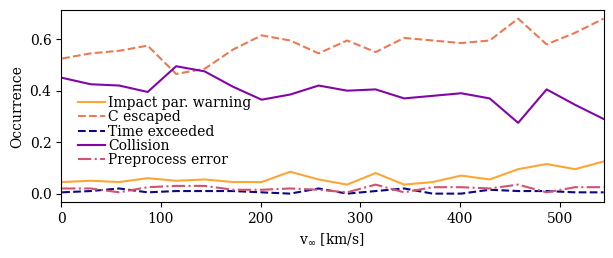

In [ ]:
colors_plasma = plt.get_cmap('plasma', 16)
print(colors_plasma)
fig, ax = plt.subplots(figsize=(7, 2.5))
n_caps = []
capture_cross_sections = []
ejection_rates = []
estimated_captures_array = []
v_inf_kms_list = []
for v in catalog.keys():
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]
    termination_flags[v] = catalog[v]['termination_flags']
    v_inf_kms = catalog[v]["mc"]["v_inf"] / 1e3
    v_inf_kms_list.append(v_inf_kms)

    b_err_count = termination_flags[v]["b_err_count"]/200
    P_err_count = termination_flags[v]["P_err_count"]/200
    # time_err_count = termination_flags[v]["time_err_count"]/200
    escape_C_count = termination_flags[v]["escape_C_count"]/200
    # escape_B_count = termination_flags[v]["escape_B_count"]/200
    # energy_err_count = termination_flags[v]["energy_err_count"]/200
    preprocess_err_count = termination_flags[v]["preprocess_err_count"]/200
    time_exceeded_count = termination_flags[v]["time_exceeded_count"]/200
    collision_count = termination_flags[v]["collision_count"]/200
    preprocess_err_count = termination_flags[v]["preprocess_err_count"]/200

    # ax.scatter(v_inf_kms, b_err_count, color=colors_plasma(12), s=15)
    # # ax.scatter(v_inf_kms, P_err_count, color=colors_plasma(2), s=15)
    # # ax.scatter(v_inf_kms, time_err_count, color=colors_plasma(14), s=15)
    # ax.scatter(v_inf_kms, escape_C_count, color=colors_plasma(10), s=15)
    # # ax.scatter(v_inf_kms, escape_B_count, color=colors_plasma(8), s=15)
    # # ax.scatter(v_inf_kms, energy_err_count, color=colors_plasma(6), s=15)
    # ax.scatter(v_inf_kms, time_exceeded_count, color=colors_plasma(0), s=15)
    # ax.scatter(v_inf_kms, collision_count, color=colors_plasma(4), s=15)

v_inf_kms_array = np.array(v_inf_kms_list)
b_err_array = np.array([termination_flags[t]["b_err_count"] for t in termination_flags.keys()])/200
# P_err_array = np.array([termination_flags[t]["P_err_count"] for t in termination_flags.keys()])/200
# time_err_array = np.array([termination_flags[t]["time_err_count"] for t in termination_flags.keys()])/200
escape_C_array = np.array([termination_flags[t]["escape_C_count"] for t in termination_flags.keys()])/200
# escape_B_array = np.array([termination_flags[t]["escape_B_count"] for t in termination_flags.keys()])/200
# energy_err_array = np.array([termination_flags[t]["energy_err_count"] for t in termination_flags.keys()])/200
time_exceeded_array = np.array([termination_flags[t]["time_exceeded_count"] for t in termination_flags.keys()])/200
collision_array = np.array([termination_flags[t]["collision_count"] for t in termination_flags.keys()])/200
preprocess_array = np.array([termination_flags[t]["preprocess_err_count"] for t in termination_flags.keys()])/200
# Sort for plotting lines
sorted_indices = np.argsort(v_inf_kms_array)
formatted_labels = [f'{v:.0f}' for v in v_inf_kms_array[sorted_indices]]
ax.plot(v_inf_kms_array[sorted_indices], b_err_array[sorted_indices], label='Impact par. warning', color=colors_plasma(12), linestyle='-')
# ax.plot(v_inf_kms_array[sorted_indices], P_err_array[sorted_indices], label=r'Invalid P', color=colors_plasma(3), linestyle='-')
# ax.plot(v_inf_kms_array[sorted_indices], time_err_array[sorted_indices], label='Invalid dt', color=colors_plasma(14), linestyle='--')
ax.plot(v_inf_kms_array[sorted_indices], escape_C_array[sorted_indices], label='C escaped', color=colors_plasma(10), linestyle='--')
# ax.plot(v_inf_kms_array[sorted_indices], escape_B_array[sorted_indices], label='B escaped', color=colors_plasma(8), linestyle=':')
# ax.plot(v_inf_kms_array[sorted_indices], energy_err_array[sorted_indices], label='Energy error', color=colors_plasma(6), linestyle='--')
ax.plot(v_inf_kms_array[sorted_indices], time_exceeded_array[sorted_indices], label='Time exceeded', color=colors_plasma(0), linestyle='--')
ax.plot(v_inf_kms_array[sorted_indices], collision_array[sorted_indices], label='Collision', color=colors_plasma(4), linestyle='-')
ax.plot(v_inf_kms_array[sorted_indices], preprocess_array[sorted_indices], label='Preprocess error', color=colors_plasma(8), linestyle='-.')
ax.set_xlabel(r'v$_\infty$ [km s$^{-1}$]')
ax.set_xlim(0, np.max(v_inf_kms_array))
# ax.set_xticks(v_inf_kms_array[sorted_indices], labels=formatted_labels, rotation=45)
# ax.set_yscale('log')
ax.set_ylabel('Occurrence')

ax.legend(loc='upper left', frameon=False, bbox_to_anchor=(0.01, 0.61), labelspacing=0.02,  handletextpad=0.2, borderpad=0.3)
plt.savefig(f'../plots/{name}/Occurrences_Rates_vs_vinf.png', dpi=300)
plt.show()

Lehmann 2021, below eq 32: N_eq = 0.1 au^3 * n_inf 
where n_inf is number densiity at infinity

[{'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_0_42.npz', 'i': 0, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_0_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_100_42.npz', 'i': 100, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_100_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_101_42.npz', 'i': 101, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_101_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_102_42.npz', 'i': 102, 'data': NpzFile '/data/a.saricaog

KeyError: 'm1 is not a file in the archive'

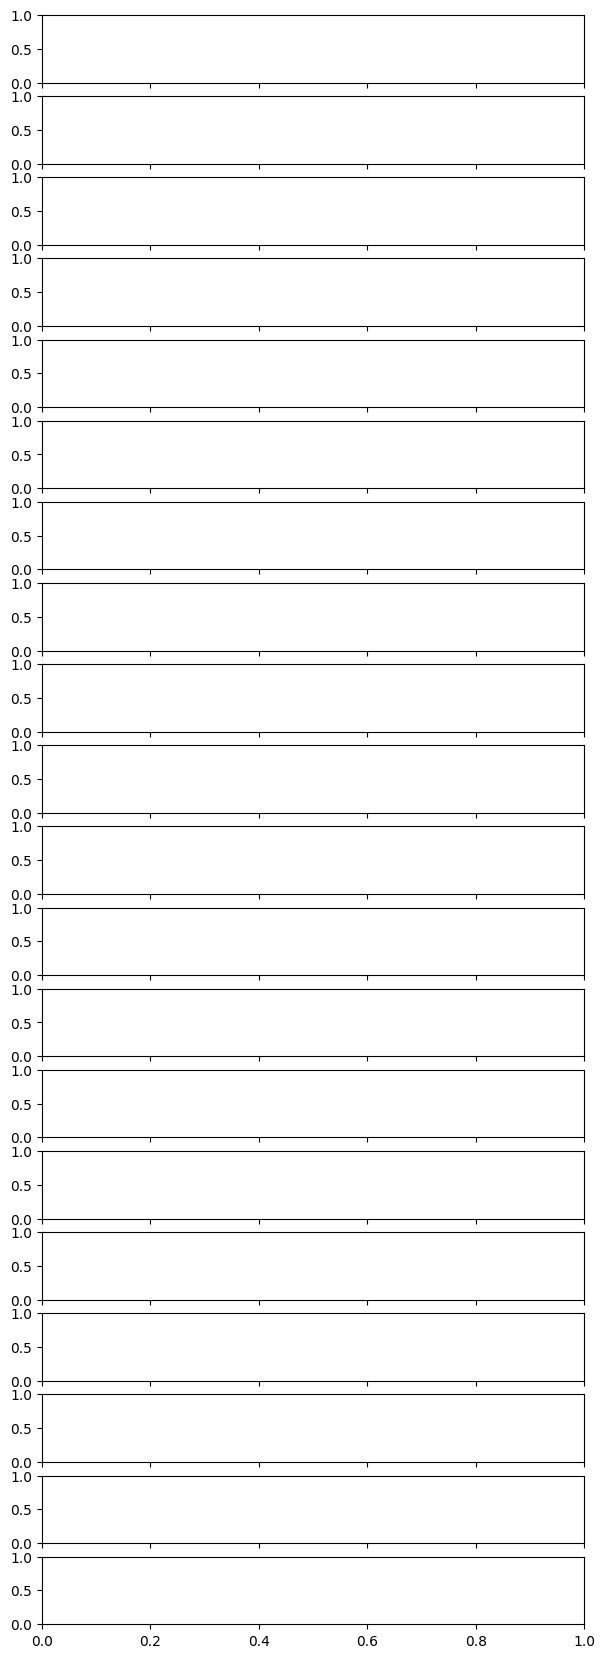

In [ ]:
colors_plasma = plt.get_cmap('plasma', len(catalog.keys()) + 1)
fig, ax = plt.subplots(20, 1, figsize=(7, 20.9), sharex='col')
# plotting histograms from the catalog
i = 0
sorted_catalog_keys = sorted(catalog.keys(), key=lambda x: int(x[1:]))  # sort by v_inf value
for v in sorted_catalog_keys:
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]
    print(orbsim_data)
    n_captured = mc_data["data"]['n_captured'] if mc_data is not None else 0
    # Skip if no MC data
    if n_captured == 0:
        continue

     # Arrays of per-capture parameters saved by MC

    a_mc_au = mc_data["data"]['a_au']
    e_mc = mc_data["data"]['e']

    a_mean_rebound = []
    e_mean_rebound = []
    op_mean_rebound = []
    for entry in orbsim_data:
        data = entry["data"]
        if "semi_major_axes" in data.files and "eccentricities" in data.files:
            a_mean_rebound.append(np.mean(data["semi_major_axes"]))
            e_mean_rebound.append(np.mean(data["eccentricities"]))
            op_mean_rebound.append(calc.orbital_period(np.mean(data["semi_major_axes"]), mA, m_PBH))
    a_mean_rebound = np.array(a_mean_rebound)

    plt.rcParams.update({'font.family': 'serif'})

    

    ax[i].hist(a_mc_au, bins=50, alpha=0.7, density=True, color=colors_plasma(0))
    ax[i].hist(a_mean_rebound, bins=50, alpha=0.7, density=True, color=colors_plasma(7))
    ax[i].text(0.1, 0.8, fr'v$_\infty$ = {mc_data["v_inf"]/1e3:.1f} km/s', transform=ax[i].transAxes)

    # ax[i].set_xlabel('Semi-Major Axis (a) [AU]')
    # ax[0].set_ylabel('Probability density')
    ax[i].set_yscale('log')
    # ax[i][1].set_xlabel('Eccentricity (e)')
    # ax[1].set_ylabel('Probability density')
    # ax[i][1].set_yscale('log')
    i += 1
ax[i-1].set_xlabel('Semi-Major Axis [AU]')
fig.tight_layout(h_pad=.15, w_pad=0.4, )
fig.text(0.02, 0.5, 'Probability density', va='center', rotation='vertical')
plt.savefig(f'../plots/{name}/Comparison_MC_Rebound_SemiMajorAxis.png', dpi=300)
plt.show()

In [18]:
print(m_PBH)

1.988409870698051e+30


[{'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_0_42.npz', 'i': 0, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_0_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_100_42.npz', 'i': 100, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_100_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_101_42.npz', 'i': 101, 'data': NpzFile '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_101_42.npz' with keys: i, v_inf, start_info, errors, start_distances...}, {'path': '/data/a.saricaoglu/repo/captus/runs/IntBH_Star/Rebound_Simulation_Results/v1/sim_102_42.npz', 'i': 102, 'data': NpzFile '/data/a.saricaog

/tmp/ipykernel_914984/3834935971.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/tmp/ipykernel_914984/3834935971.py:115: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


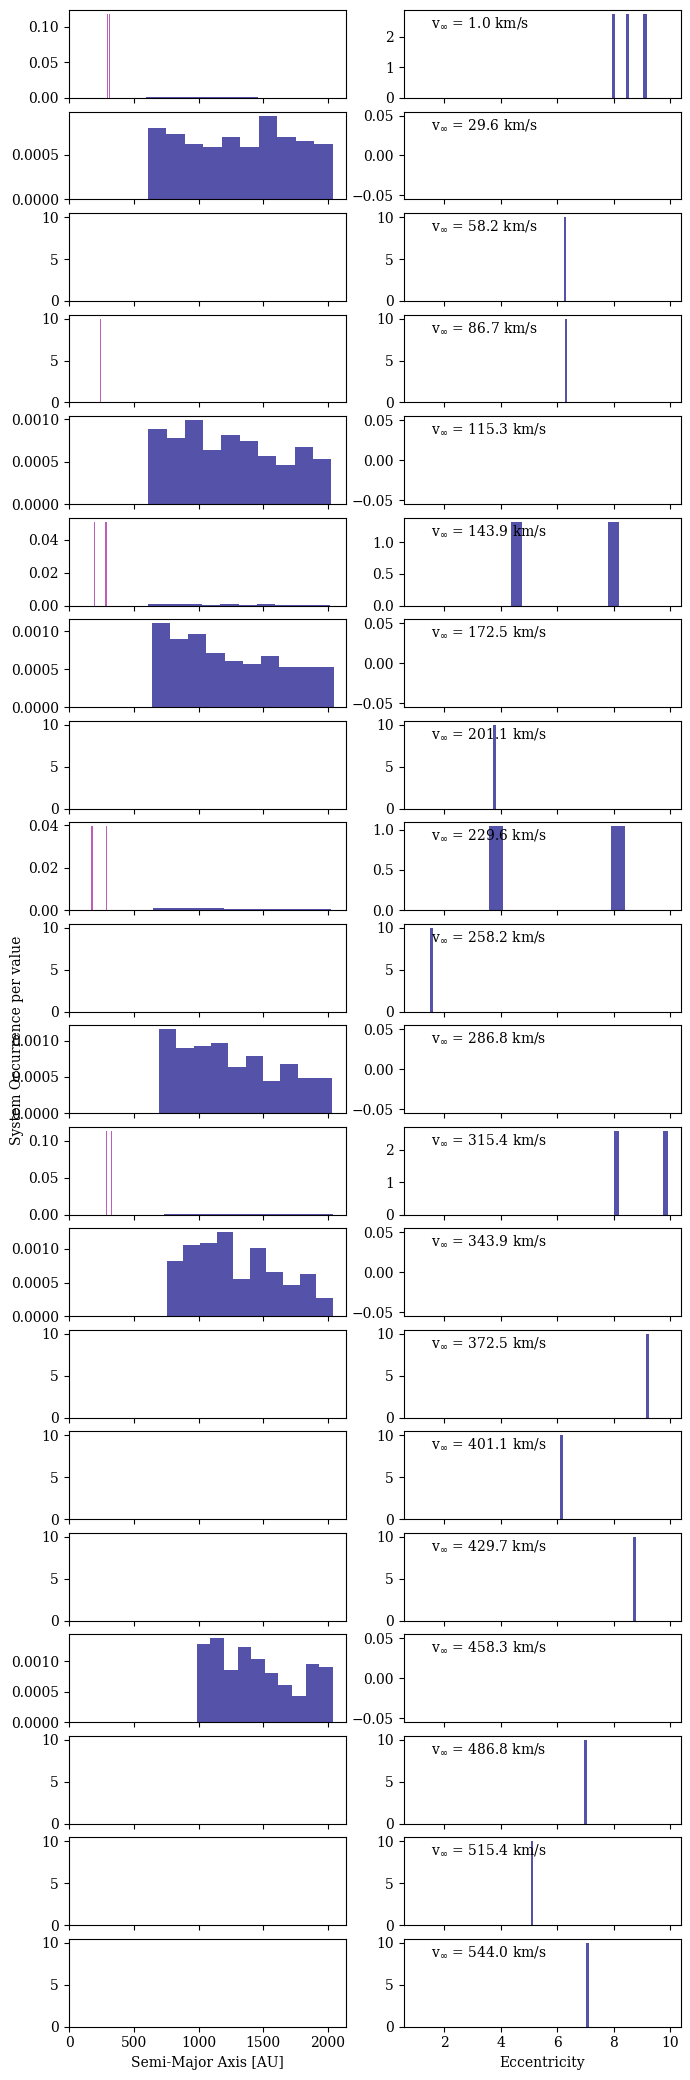

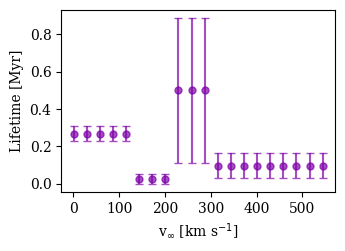

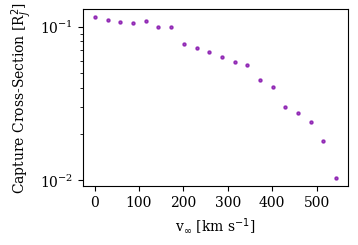

In [23]:
from scipy.stats import bootstrap
name="Sun_Jupiter_lightPBH"
colors_plasma = plt.get_cmap('plasma', len(catalog.keys()) + 1)
fig, ax = plt.subplots(20, 2, figsize=(7, 20.9), sharex='col')
fig1, ax1 = plt.subplots(1, 1, figsize=(3.5, 2.5), sharex='col')
fig2, ax2 = plt.subplots(1, 1, figsize=(3.5, 2.5), sharex='col')
# plotting histograms from the catalog
i = 0
sorted_catalog_keys = sorted(catalog.keys(), key=lambda x: int(x[1:]))  # sort by v_inf value
for v in sorted_catalog_keys:
    mc_data = catalog[v]["mc"]
    orbsim_data = catalog[v]["rebound"]

    print(orbsim_data)
    n_captured = mc_data["data"]['n_captured'] if mc_data is not None else 0
    # Skip if no MC data
    if n_captured == 0:
        continue

     # Arrays of per-capture parameters saved by MC

    a_mc_au = mc_data["data"]['a_au']
    e_mc = mc_data["data"]['e']

    crossection = mc_data["data"]['sigma_MC_areaB']  # in au^2

    a_mean_rebound = []
    e_mean_rebound = []
    op_mean_rebound = []
    a_mean_rebound0 = []
    e_mean_rebound0 = []

    lifetimes = []
    lifetimes0 = []
    crossections = []
    crossections0 = []
     # Arrays of per-capture parameters saved by Rebound simulations
    for rebound in orbsim_data:

        rebound = rebound["data"]

        if "semi_major_axes" in rebound.files and "eccentricities" in rebound.files:

            a_mean_rebound.append(np.mean(rebound["semi_major_axes"]))
            e_mean_rebound.append(np.mean(rebound["eccentricities"]))
            op_mean_rebound.append(calc.orbital_period((np.mean(rebound["semi_major_axes"])*u.au).to(u.m).value, mA, m_PBH))

            lifetimes.append(rebound["lifetime"])



    a_mean_rebound = np.array(a_mean_rebound)
    e_mean_rebound = np.array(e_mean_rebound)
    op_mean_rebound = (np.array(op_mean_rebound)*u.second).to(u.yr).value 
    lifetimes = np.array(lifetimes)/1e6  # convert to Myr
    a_mean_rebound_less_than_1yr = a_mean_rebound[op_mean_rebound < 10]
    e_mean_rebound_less_than_1yr = e_mean_rebound[op_mean_rebound < 10]
    lifetimes = lifetimes[op_mean_rebound < 10]
    op_mean_rebound = op_mean_rebound[op_mean_rebound < 10]


    # Bootstrap a 68% CI around the MEAN lifetime, not the std
    if lifetimes.size > 1 and np.all(np.isfinite(lifetimes)):
        res = bootstrap((lifetimes,), np.mean, confidence_level=0.68, n_resamples=10000, method='basic', rng=np.random.default_rng(42))
        lifetime_ci_low, lifetime_ci_high = res.confidence_interval
        lifetime_mean = float(np.mean(lifetimes))
        # Build asymmetric error bars as 2xN (here N=1)
        yerr = np.array([[lifetime_mean - lifetime_ci_low],
                         [lifetime_ci_high - lifetime_mean]])

    v_inf_kms = mc_data["v_inf"]/1e3
    print(f'min lifetime  {np.nanmin(lifetimes) if lifetimes.size else np.nan} Myr max lifetime {np.nanmax(lifetimes) if lifetimes.size else np.nan} Myr')
    print(f'ci lifetime  {lifetime_ci_low if lifetimes.size>1 else np.nan} - {lifetime_ci_high if lifetimes.size>1 else np.nan} Myr mean lifetime {lifetime_mean} Myr')
    plt.rcParams.update({'font.family': 'serif'})

    
    bins_a = np.linspace(0, 1000, 30)
    bins_e = np.linspace(0, 1, 20)
    
    ax[i][0].hist(a_mc_au, bins=10, alpha=0.7, density=True, color=colors_plasma(0))
    ax[i][0].hist(a_mean_rebound_less_than_1yr, bins=10, alpha=0.7, density=True, color=colors_plasma(7))
    ax[i][1].text(0.1, 0.8, fr'v$_\infty$ = {mc_data["v_inf"]/1e3:.1f} km/s', transform=ax[i][1].transAxes)
    ax[i][1].hist(op_mean_rebound, bins=10, alpha=0.7, density=True, color=colors_plasma(0))
    # ax[i][1].hist(e_mean_rebound, bins=30, alpha=0.7, density=True, color=colors_plasma(7))

    # Errorbar expects 2xN for asymmetric errors; x must be 1D
    ax1.errorbar([v_inf_kms], [lifetime_mean], yerr=yerr, marker='o', capsize=3, markersize=5, alpha=0.7, color=colors_plasma(5))
    ax2.scatter([v_inf_kms], [crossection], marker='o', s=5, alpha=0.7, color=colors_plasma(5))
    # ax[i][0].set_xlabel('Semi-Major Axis (a) [AU]')
    # ax[0].set_ylabel('Probability density')
    # ax[i][0].set_yscale('log')
    # ax[i][1].set_xlabel('Eccentricity (e)')
    # ax[1].set_ylabel('Probability density')
    # ax[i][1].set_yscale('log')
    i += 1
ax[i-1][0].set_xlabel('Semi-Major Axis [AU]')
ax[i-1][1].set_xlabel('Eccentricity')
# ax1.set_yscale('log')
fig.tight_layout(h_pad=.15, w_pad=0.4)
fig.text(0.02, 0.5, 'System Occurrence per value', va='center', rotation='vertical')
fig1.tight_layout(h_pad=.15, w_pad=0.4, pad=1.6)
fig2.tight_layout(h_pad=.15, w_pad=0.4, pad=1.6)
ax1.set_ylabel('Lifetime [Myr]')
ax1.set_xlabel(r'v$_\infty$ [km s$^{-1}$]')
ax2.set_ylabel('Capture Cross-Section [R$_J^2$]')
ax2.set_xlabel(r'v$_\infty$ [km s$^{-1}$]')
ax2.set_yscale('log')
# fig1.legend(handles=[ax1.scatter([v_inf_kms], [lifetime_mean], marker='o', alpha=0.7, color=colors_plasma(5), label=r'M$_{PBH}$ = 10$^{-3}$ M$_\odot$'),
#                      ax1.scatter([v_inf_kms], [lifetime_mean0], marker='o', alpha=0.7, color=colors_plasma(2), label=r'M$_{PBH}$ = 10$^{-14}$ M$_\odot$')],
#            loc='upper left', frameon=False, bbox_to_anchor=(0.07, 0.92), labelspacing=0.01, fontsize=8, handletextpad=0.001, borderpad=0.3, markerscale=1)
fig1.savefig(f'../plots/{name}/Comparison_MC_Rebound_Lifetime.png', dpi=300)
# plt.savefig(f'../plots/{name}/Comparison_MC_Rebound_SemiMajorAxis_Eccentricity_Lifetime.png', dpi=300)
fig1.show()
fig2.savefig(f'../plots/{name}/Comparison_MC_Rebound_CaptureCrossSection.png', dpi=300)
fig2.show()


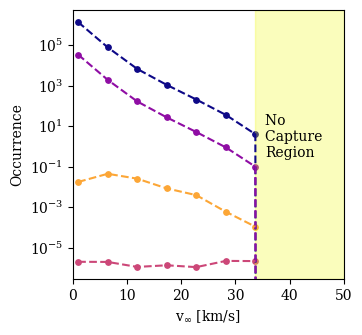

In [ ]:
# plot occurences per v_inf  
fig, ax = plt.subplots(figsize=(3.5, 3.5))
n_caps = []
capture_cross_sections = []
ejection_rates = []
estimated_captures_array = []
v_inf_kms_list = []
for v in occurrences.keys():
    v_inf_kms = catalog[v]["mc"]["v_inf"] / 1e3  # km/s
    n_captured = occurrences[v]['n_captured']
    capture_cross_section = occurrences[v]['capture_cross_section_areaB']
    ejection_rate = occurrences[v]['ejection_rate_1_per_yr']
    estimated_captures = occurrences[v]['estimated_captures']
    v_inf_kms_list.append(v_inf_kms)
    capture_cross_sections.append(capture_cross_section)
    n_caps.append(n_captured)
    ejection_rates.append(ejection_rate)
    estimated_captures_array.append(estimated_captures)
    ax.scatter(v_inf_kms, n_captured, label='Number Captured', color=colors_plasma(0), s=15)
    ax.scatter(v_inf_kms, capture_cross_section, label=r'Capture Cross-Section (Area$_B$)', color=colors_plasma(3), s=15)
    ax.scatter(v_inf_kms, ejection_rate, label='Ejection Rate (1/yr)', color=colors_plasma(5), s=15)
    ax.scatter(v_inf_kms, estimated_captures, label='Estimated Captures', color=colors_plasma(8), s=15)
v_inf_kms_array = np.array(v_inf_kms_list)
n_caps_array = np.array(n_caps)
capture_cross_sections_array = np.array(capture_cross_sections)
ejection_rates_array = np.array(ejection_rates)
estimated_captures_array = np.array(estimated_captures_array)
# Sort for plotting lines
sorted_indices = np.argsort(v_inf_kms_array)
ax.plot(v_inf_kms_array[sorted_indices], n_caps_array[sorted_indices], color=colors_plasma(0), linestyle='--')
ax.plot(v_inf_kms_array[sorted_indices], capture_cross_sections_array[sorted_indices], color=colors_plasma(3), linestyle='--')
ax.plot(v_inf_kms_array[sorted_indices], ejection_rates_array[sorted_indices], color=colors_plasma(5), linestyle='--')
ax.plot(v_inf_kms_array[sorted_indices], estimated_captures_array[sorted_indices], color=colors_plasma(8), linestyle='--')
ax.set_xlabel(r'v$_\infty$ [km s$^{-1}$]')
ax.set_xlim(0, np.max(v_inf_kms_array))
ax.set_yscale('log')
ax.set_ylabel('Occurrence')
# Shade after the last v_inf that has rates to the end of the plot
xmax = ax.get_xlim()[1]
mask = np.isfinite(ejection_rates_array) & (ejection_rates_array > 0)
if np.any(mask):
    x_last = np.max(v_inf_kms_array[mask])
else:
    x_last = np.max(v_inf_kms_array)
ax.axvspan(x_last, xmax, color=colors_plasma(10), alpha=0.3)
ax.text(x_last + 0.11*(xmax - x_last), 0.3, 'No \nCapture \nRegion', color='black', alpha=1 )
# ax.legend()
plt.savefig(f'../plots/{name}/Occurrences_Rates_vs_vinf.png', dpi=300)
plt.show()


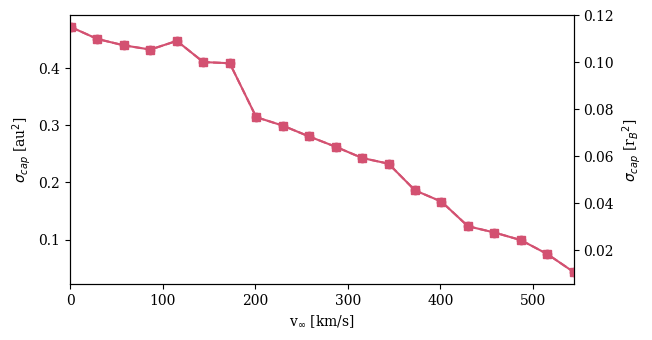

In [ ]:
# Plot capture cross-section vs v_inf with dual y-axes (AU^2 and Area_B)
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

# Collect data from catalog
v_vals_kms = []
sigma_au2 = []
sigma_areaB = []

# Ensure keys are sorted by numeric v (strip 'v' prefix)
sorted_keys = sorted(catalog.keys(), key=lambda k: int(k[1:]))
for vk in sorted_keys:
    mc_entry = catalog[vk]["mc"]
    if mc_entry is None:
        continue
    v_inf_mps = float(mc_entry["v_inf"])  # m/s
    v_vals_kms.append(v_inf_mps / 1e3)
    mc_pkg = mc_entry["data"]
    # Convert stored sigma in m^2 to AU^2
    sig_m2 = float(mc_pkg["sigma_MC_m2"])  # m^2
    sig_au2 = (sig_m2 * u.m**2).to(u.au**2).value
    sigma_au2.append(sig_au2)
    # Area_B is already unitless scaling of B's area in AU^2 equivalent domain (from MC)
    sigma_areaB.append(float(mc_pkg["sigma_MC_areaB"]))

v_vals_kms = np.array(v_vals_kms)
sigma_au2 = np.array(sigma_au2)
sigma_areaB = np.array(sigma_areaB)

# Sort arrays by v for cleaner plotting
order = np.argsort(v_vals_kms)
v_plot = v_vals_kms[order]
sigma_au2_plot = sigma_au2[order]
sigma_areaB_plot = sigma_areaB[order]

plt.rcParams.update({'font.family': 'serif'})
fig, ax_left = plt.subplots(2, 1, figsize=(7, 5))
ax_right = ax_left.twinx()

# Left axis: AU^2
ax_left.plot(v_plot, sigma_au2_plot, color=colors_plasma(8), marker='o', linestyle='--', label='Capture Cross-Section (AU^2)')
ax_left.set_ylabel(r'$\sigma_{cap}$ [au$^2$]')
ax_left.tick_params(axis='y')
# ax_left.set_yscale('log')

# Right axis: Area_B units
ax_right.plot(v_plot, sigma_areaB_plot, color=colors_plasma(8), marker='s', linestyle='-', label='Capture Cross-Section (Area_B)')
ax_right.set_ylabel(r'$\sigma_{cap}$ [r$_B$$^2$]')
ax_right.tick_params(axis='y')
# ax_right.set_yscale('log')

ax_left.set_xlabel(r'v$_\infty$ [km s$^{-1}$]')
ax_left.set_xlim(0, np.max(v_plot))


# Optional: save to plots directory if name exists in notebook context
try:
    plt.savefig(f'../plots/{name}/Capture_CrossSection_vs_vinf_dual_axes.png', dpi=300)
except Exception:
    pass
plt.show()

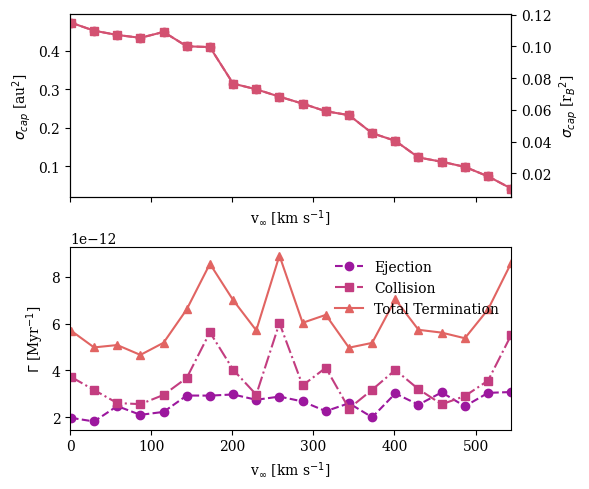

In [185]:
# Combined figure: (top) dual-axis cross-section; (bottom) ejection/collision/total termination rates
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

# --- Collect MC cross-sections ---
v_vals_kms = []
sigma_au2 = []
sigma_areaB = []

sorted_keys = sorted(catalog.keys(), key=lambda k: int(k[1:]))
for vk in sorted_keys:
    mc_entry = catalog[vk]["mc"]
    if mc_entry is None:
        continue
    v_inf_mps = float(mc_entry["v_inf"])  # m/s
    v_vals_kms.append(v_inf_mps / 1e3)
    mc_pkg = mc_entry["data"]
    sig_m2 = float(mc_pkg["sigma_MC_m2"])  # m^2
    sig_au2 = (sig_m2 * u.m**2).to(u.au**2).value
    sigma_au2.append(sig_au2)
    sigma_areaB.append(float(mc_pkg["sigma_MC_areaB"]))

v_vals_kms = np.array(v_vals_kms)
sigma_au2 = np.array(sigma_au2)
sigma_areaB = np.array(sigma_areaB)
order = np.argsort(v_vals_kms)
v_plot = v_vals_kms[order]
sigma_au2_plot = sigma_au2[order]
sigma_areaB_plot = sigma_areaB[order]

# --- Collect termination rates from previously built occurrences dict ---
# Expect keys: 'ejection_rate_1_per_yr', 'collision_rate_1_per_yr', 'termination_rate_1_per_yr'
v_rates = []
eject_rates = []
coll_rates = []
total_rates = []
for vk in sorted_keys:
    if vk not in occurrences:
        continue
    mc_entry = catalog[vk]["mc"]
    v_rates.append(float(mc_entry["v_inf"]) / 1e3)
    eject_rates.append(occurrences[vk].get('ejection_rate_1_per_yr', np.nan))
    coll_rates.append(occurrences[vk].get('collision_rate_1_per_yr', np.nan))
    total_rates.append(occurrences[vk].get('termination_rate_1_per_yr', np.nan))

v_rates = np.array(v_rates)
eject_rates = np.array(eject_rates)
coll_rates = np.array(coll_rates)
total_rates = np.array(total_rates)
order_r = np.argsort(v_rates)
v_rates_plot = v_rates[order_r]
eject_plot = eject_rates[order_r]/1e6  # convert to 1/Myr
coll_plot = coll_rates[order_r]/1e6  # convert to 1/Myr
total_plot = total_rates[order_r]/1e6  # convert to 1/Myr

plt.rcParams.update({'font.family': 'serif'})
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(6, 5))

# Top: dual-axis cross-section
ax_left = ax_top
ax_right = ax_left.twinx()
ax_left.plot(v_plot, sigma_au2_plot, color=colors_plasma(8), marker='o', linestyle='--', label='Capture Cross-Section (AU^2)')
ax_left.set_ylabel(r'$\sigma_{cap}$ [au$^2$]')
ax_left.tick_params(axis='y')
# ax_left.set_yscale('log')

# Right axis: Area_B units
ax_right.plot(v_plot, sigma_areaB_plot, color=colors_plasma(8), marker='s', linestyle='-', label='Capture Cross-Section (Area_B)')
ax_right.set_ylabel(r'$\sigma_{cap}$ [r$_B$$^2$]')
ax_right.tick_params(axis='y')
# ax_right.set_yscale('log')

ax_left.set_xlabel(r'v$_\infty$ [km s$^{-1}$]')
ax_left.set_xlim(0, np.max(v_plot))
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()

# Bottom: termination rates
ax_rates = ax_bottom
ax_rates.plot(v_rates_plot, eject_plot, color=colors_plasma(5), marker='o', linestyle='--', label='Ejection')
ax_rates.plot(v_rates_plot, coll_plot, color=colors_plasma(7), marker='s', linestyle='-.', label='Collision')
ax_rates.plot(v_rates_plot, total_plot, color=colors_plasma(9), marker='^', linestyle='-', label='Total Termination')
ax_rates.set_xlabel(r'v$_\infty$ [km s$^{-1}$]')
ax_rates.set_ylabel(r'$\Gamma$ [Myr$^{-1}$]')
ax_rates.set_xlim(0, np.max(v_rates_plot) if v_rates_plot.size else 1)
# ax_rates.set_yscale('log')
ax_rates.legend(loc='upper right', frameon=False)

fig.tight_layout(h_pad=0.35)
try:
    plt.savefig(f'../plots/{name}/CrossSection_and_TerminationRates_vs_vinf.png', dpi=300)
except Exception:
    pass
plt.show()